# ML Model Comparison — Amazon Bestsellers Reviews
**Target**: `is_helpful` — predicting whether a review was found helpful.

Six model families evaluated:
1. **KNN** — k-Nearest Neighbors
2. **Decision Tree**
3. **Random Forest**
4. **XGBoost**
5. **Logistic Regression** (L1 and L2)
6. **SVM** — Linear Support Vector Machine (L1 and L2)

Primary comparison metric: **MC Mean** over 30 random splits (`random_state=MC_SEED`).
All train/test accuracy values reported from MC sweep means at best hyperparameter — not fixed split.


## 0. Imports & Setup

In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
from warnings import simplefilter
from sklearn.exceptions import ConvergenceWarning
simplefilter('ignore', category=ConvergenceWarning)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, ShuffleSplit, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, RocCurveDisplay)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.style.use('dark_background')

MC_SEED    = 30
N_MC_SWEEP = 30
N_MC_FINAL = 30


##TF-IDF not used for any models

TF-IDF matrices were not directrly used for any of the models here, for several reasons.

1. Sentiment strength and sentiment_is_positive already capture how strong the sentiment is and whether it is positive and negative.

2. Review descriptors such as body_len, title_len and avg_word_len is also already here.

Together, this shows the emotion and its direction as well as details about the amount of effort put into the review, and there is no need for the model to focus on specific words used, especially since the model is expected to work regardless of type of product.

When TF-IDF was applied for the tree models (Not the linear ones since TF-IDF matrices are sparse) the accuracy was either not significantly impacted and in some cases, actually lowered. It also cluttered the feature importances by showing specific words that generally imply the same thing or words that are too product category specific, and even hid interesting feature importance results.

## 1. Data Loading & Preprocessing

In [ ]:
df = pd.read_csv('amazon_bestsellers_reviews_cleaned.csv')
df['image_count'].value_counts().sort_index()


,count
image_count,
0,1294
1,119
2,46
3,21
4,15
5,4
6,5
7,1
8,2


In [ ]:
df = pd.read_csv('amazon_bestsellers_reviews_cleaned.csv')

DROP_COLS = [
    'helpful_votes',           # data leakage
    'verified',                # zero variance
    'product_url',             # identifier
    'reviewer',                # high-cardinality identifier
    'product_name',            # high-cardinality identifier
    'product_index',           # arbitrary index
    'text_for_lsa',            # raw text
    'title',                   # raw text
    'body',                    # raw text
    'location',                # exposure bias proxy
    'variant',                 # 732 unique values
    'date',
    'department_Clothing, Shoes & Jewelry',
    'department_Electronics',
    'department_Kitchen & Home',
    'word_count',
]

X = df.drop(DROP_COLS + ['is_helpful'], axis=1)
y = df['is_helpful']

categorical_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
numerical_cols   = X.select_dtypes(exclude=['object', 'string']).columns.tolist()

print(f"Samples : {X.shape[0]}")
print(f"Features: {X.shape[1]}  ({len(numerical_cols)} numerical, {len(categorical_cols)} categorical)")
print(f"Features: {numerical_cols + categorical_cols}")
print(f"Target  : {y.value_counts().to_dict()} (1 = helpful)")


Samples : 1513
Features: 8  (8 numerical, 0 categorical)
Features: ['rating', 'image_count', 'rating_mid_dist', 'title_len', 'body_len', 'avg_word_len', 'sentiment_strength', 'sentiment_is_positive']
Target  : {1: 924, 0: 589} (1 = helpful)


In [ ]:
X.head()


,rating,image_count,rating_mid_dist,title_len,body_len,avg_word_len,sentiment_strength,sentiment_is_positive
0,5,0,2,31,557,6.258427,0.9876,1
1,5,0,2,23,495,6.036585,0.9547,1
2,5,0,2,56,1369,6.251142,0.9857,1
3,5,0,2,31,935,5.843750,0.9953,1
4,5,0,2,51,132,5.076923,0.9705,1


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train: {X_train.shape[0]}  |  Test: {X_test.shape[0]}")
print(f"Train class balance: {y_train.mean():.3f}  |  Test class balance: {y_test.mean():.3f}")

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_cols),
] + ([('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)]
     if categorical_cols else []))


Train: 1210  |  Test: 303
Train class balance: 0.611  |  Test class balance: 0.611


### Monte Carlo & Plotting Helpers

In [ ]:
def mc_sweep(make_pipeline_fn, param_values, n_splits=N_MC_SWEEP,
             X_data=None, y_data=None):
    X_use = X_data if X_data is not None else X
    y_use = y_data if y_data is not None else y
    ss = ShuffleSplit(n_splits=n_splits, test_size=0.25, random_state=MC_SEED)
    all_train = np.zeros((len(param_values), n_splits))
    all_test  = np.zeros((len(param_values), n_splits))
    for j, (tr_idx, te_idx) in enumerate(ss.split(X_use, y_use)):
        X_tr, X_te = X_use.iloc[tr_idx], X_use.iloc[te_idx]
        y_tr, y_te = y_use.iloc[tr_idx], y_use.iloc[te_idx]
        for i, val in enumerate(param_values):
            m = make_pipeline_fn(val)
            m.fit(X_tr, y_tr)
            all_train[i, j] = m.score(X_tr, y_tr)
            all_test[i, j]  = m.score(X_te, y_te)
    return all_train, all_test


def plot_mc_bands(param_values, all_train, all_test, xlabel, title,
                  best_val=None, best_label=None, x_labels=None):
    tr_mean, tr_std = all_train.mean(1), all_train.std(1)
    te_mean, te_std = all_test.mean(1),  all_test.std(1)
    xs = range(len(param_values))

    fig, ax = plt.subplots(figsize=(16, 9), facecolor='black')
    ax.set_facecolor('black')
    ax.plot(xs, tr_mean, 'o-', color='steelblue',  label='Train (mean)', lw=2)
    ax.fill_between(xs, tr_mean-tr_std, tr_mean+tr_std, alpha=0.35, color='steelblue', label='Train ±1 std')
    ax.plot(xs, te_mean, 's-', color='darkorange', label='Test (mean)',  lw=2)
    ax.fill_between(xs, te_mean-te_std, te_mean+te_std, alpha=0.35, color='darkorange', label='Test ±1 std')
    if best_val is not None and best_label is not None:
        vals_list = list(param_values)
        if best_val in vals_list:
            ax.axvline(vals_list.index(best_val), color='red', ls='--', alpha=0.7,
                       label=f'Best: {best_label}')
    ax.set_xticks(xs)
    ax.set_xticklabels(x_labels if x_labels else [str(v) for v in param_values],
                       color='white', fontweight='bold')
    ax.set_xlabel(xlabel, color='white', fontweight='bold', fontsize=11)
    ax.set_ylabel('Accuracy', color='white', fontweight='bold', fontsize=11)
    ax.set_title(f'{title}\n(shaded = ±1 std across {N_MC_SWEEP} random splits, seed={MC_SEED})',
                 color='white', fontweight='bold', fontsize=12)
    ax.tick_params(colors='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')
    ax.grid(True, color='white', alpha=0.15, linestyle='--')
    legend = ax.legend(fontsize=9, facecolor='black', edgecolor='white', labelcolor='white')
    for text in legend.get_texts():
        text.set_fontweight('bold')
    plt.tight_layout()
    plt.show()


def mc_final_score(pipeline, label, X_data=None, y_data=None):
    X_use = X_data if X_data is not None else X
    y_use = y_data if y_data is not None else y
    scores = cross_val_score(pipeline, X_use, y_use,
                             cv=ShuffleSplit(N_MC_FINAL, test_size=0.25, random_state=MC_SEED),
                             scoring='accuracy', n_jobs=-1)
    mean, std = scores.mean(), scores.std()
    print(f"{label} MC ({N_MC_FINAL} splits, seed={MC_SEED}): {mean:.4f} ± {std:.4f}")
    return mean, std


def print_cm_metrics(y_true, y_pred):
    """Print confusion matrix breakdown: TP/TN/FP/FN + derived metrics."""
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    acc  = (tp + tn) / (tp + tn + fp + fn)
    prec = tp / (tp + fp) if (tp + fp) > 0 else 0
    rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
    print(f"  TP: {tp:4d}  TN: {tn:4d}  FP: {fp:4d}  FN: {fn:4d}")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall   : {rec:.4f}")
    print(f"  F1 Score : {f1:.4f}")


def plot_confusion(y_true, y_pred, title, cmap='Blues'):
    fig, ax = plt.subplots(figsize=(5, 4), facecolor='black')
    ax.set_facecolor('black')
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                cbar_kws={'label': 'Count'},
                annot_kws={'color': 'black', 'fontsize': 12})
    ax.set_title(title, fontweight='bold', color='white')
    ax.set_ylabel('True Label', color='white')
    ax.set_xlabel('Predicted Label', color='white')
    ax.tick_params(colors='white')
    ax.spines['top'].set_color('white')
    ax.spines['right'].set_color('white')
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')
    cbar = ax.collections[0].colorbar
    cbar.ax.yaxis.label.set_color('white')
    cbar.ax.tick_params(colors='white')
    plt.tight_layout()
    plt.show()


def get_top_imp(importances, n=12):
    df_i = pd.DataFrame({'feature': all_feats, 'importance': importances})
    return df_i.nlargest(n, 'importance').sort_values('importance')


param_aliases = {
    'n_neighbors':'k', 'weights':'weights', 'metric':'metric',
    'max_depth':'max_depth', 'min_samples_split':'min_split',
    'min_samples_leaf':'min_leaf', 'criterion':'criterion',
    'n_estimators':'n_est', 'max_features':'max_feat', 'learning_rate':'lr',
    'C':'C', 'penalty':'penalty',
}
def clean_params(params):
    return str({param_aliases.get(k.split('__')[-1], k.split('__')[-1]): v
                for k, v in params.items()})


---
## 2. k-Nearest Neighbors (KNN)

### Part 1 — Base Model

In [ ]:
knn_base = Pipeline([('preprocessor', preprocessor), ('knn', KNeighborsClassifier(n_neighbors=5))])
knn_base.fit(X_train, y_train)
knn_base_train_acc = knn_base.score(X_train, y_train)
knn_base_test_acc  = knn_base.score(X_test,  y_test)
print(f"KNN BASE (k=5)  Train: {knn_base_train_acc:.4f}  Test: {knn_base_test_acc:.4f}")


KNN BASE (k=5)  Train: 0.7909  Test: 0.7261


### Part 2 — GridSearchCV + MC Sweep

Best params : {'knn__metric': 'manhattan', 'knn__n_neighbors': 24, 'knn__weights': 'distance'}
CV Score    : 0.7157

MC Train (at best k=24): 0.7529
MC Test  (at best k=24): 0.7303
MC Gap                       : 0.0227


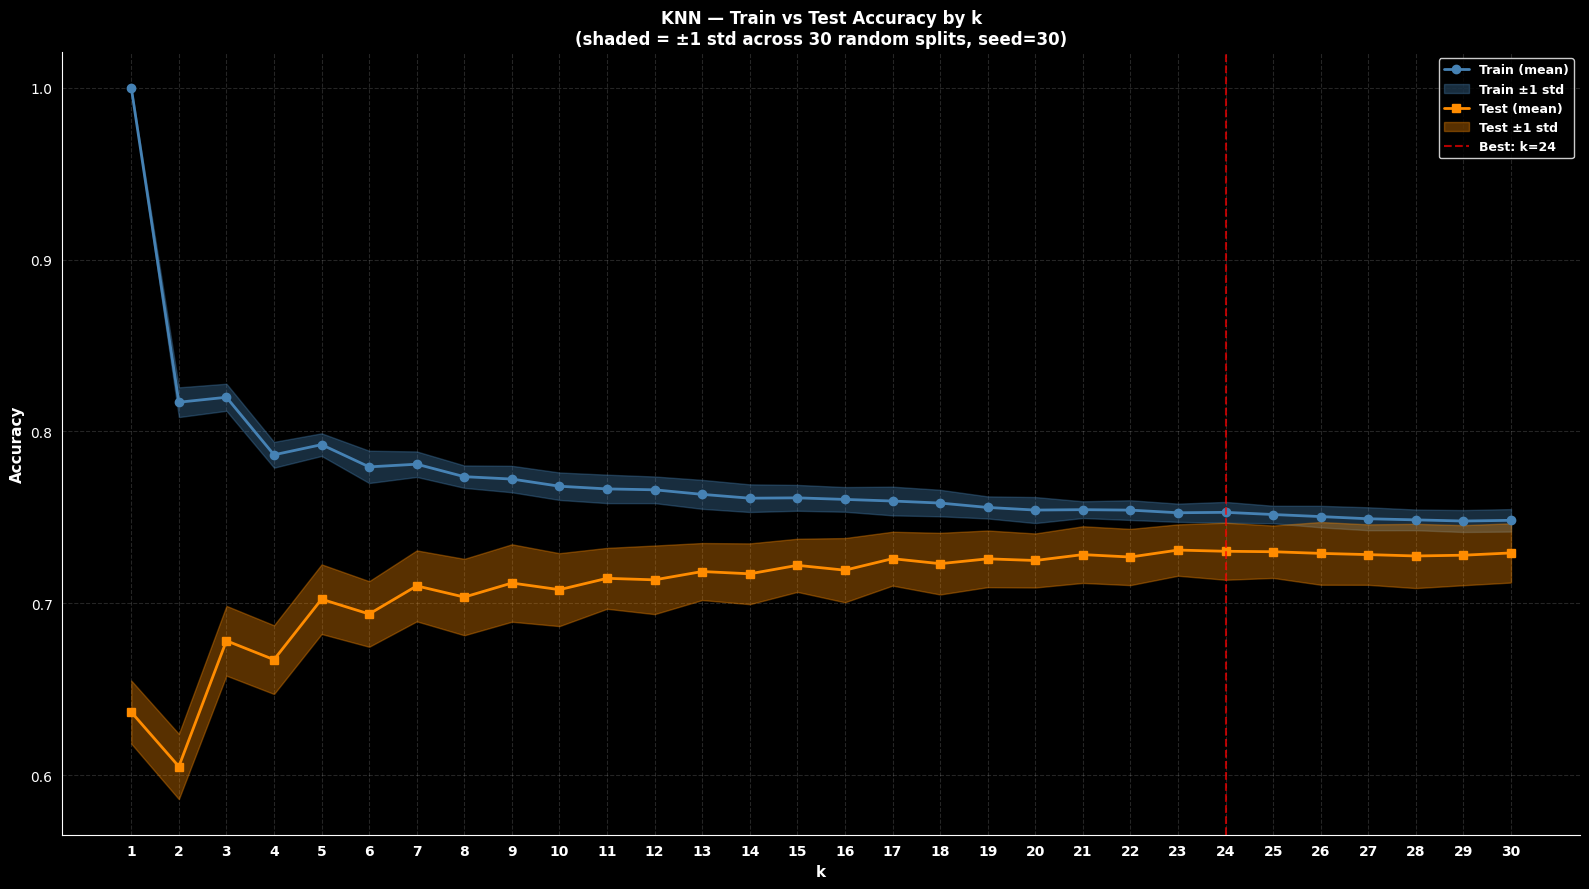

In [ ]:
knn_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor), ('knn', KNeighborsClassifier())]),
    {'knn__n_neighbors': list(range(1,31)), 'knn__weights': ['uniform','distance'],
     'knn__metric': ['euclidean','manhattan']},
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
knn_grid.fit(X_train, y_train)
knn_best      = knn_grid.best_estimator_
knn_test_pred = knn_best.predict(X_test)

print(f"Best params : {knn_grid.best_params_}")
print(f"CV Score    : {knn_grid.best_score_:.4f}")

k_values = list(range(1, 31))
knn_mc_train, knn_mc_test = mc_sweep(
    lambda k: Pipeline([('preprocessor', preprocessor),
                        ('knn', KNeighborsClassifier(n_neighbors=k, weights='uniform'))]),
    k_values
)
best_k = knn_grid.best_params_['knn__n_neighbors']
knn_mc_train_mean = knn_mc_train[k_values.index(best_k)].mean()
knn_mc_test_mean  = knn_mc_test[k_values.index(best_k)].mean()
print(f"\nMC Train (at best k={best_k}): {knn_mc_train_mean:.4f}")
print(f"MC Test  (at best k={best_k}): {knn_mc_test_mean:.4f}")
print(f"MC Gap                       : {abs(knn_mc_train_mean - knn_mc_test_mean):.4f}")
plot_mc_bands(k_values, knn_mc_train, knn_mc_test, xlabel='k',
              title='KNN — Train vs Test Accuracy by k',
              best_val=best_k, best_label=f"k={best_k}")


### MC Final Score + Confusion Matrix

KNN MC (30 splits, seed=30): 0.7247 ± 0.0175


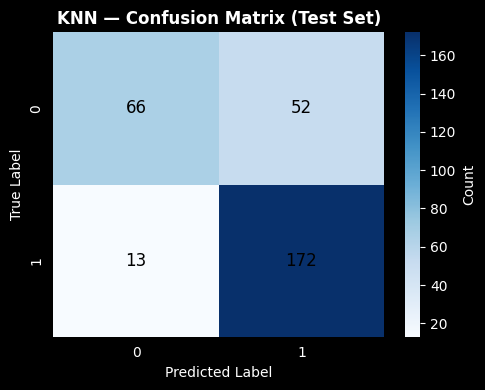


Confusion Matrix Metrics:
  TP:  172  TN:   66  FP:   52  FN:   13
  Accuracy : 0.7855
  Precision: 0.7679
  Recall   : 0.9297
  F1 Score : 0.8411


In [ ]:
knn_mc_mean, knn_mc_std = mc_final_score(knn_best, 'KNN')
plot_confusion(y_test, knn_test_pred, 'KNN — Confusion Matrix (Test Set)', cmap='Blues')
print("\nConfusion Matrix Metrics:")
print_cm_metrics(y_test, knn_test_pred)


---
## 3. Decision Tree

### Part 1 — Base Model

In [ ]:
dt_base = Pipeline([('preprocessor', preprocessor),
                    ('dt', DecisionTreeClassifier(max_depth=5, random_state=42))])
dt_base.fit(X_train, y_train)
dt_base_train_acc = dt_base.score(X_train, y_train)
dt_base_test_acc  = dt_base.score(X_test,  y_test)
dt_step = dt_base.named_steps['dt']
print(f"DT BASE (max_depth=5)  Train: {dt_base_train_acc:.4f}  Test: {dt_base_test_acc:.4f}")
print(f"Tree depth: {dt_step.get_depth()}  |  Leaves: {dt_step.get_n_leaves()}")


DT BASE (max_depth=5)  Train: 0.7587  Test: 0.7591
Tree depth: 5  |  Leaves: 26


### Part 2 — GridSearchCV + MC Sweep

Best params : {'dt__criterion': 'gini', 'dt__max_depth': 3, 'dt__min_samples_leaf': 1, 'dt__min_samples_split': 2}
CV Score    : 0.7124

MC Train (at best max_depth=3): 0.7524
MC Test  (at best max_depth=3): 0.7256
MC Gap                                   : 0.0268


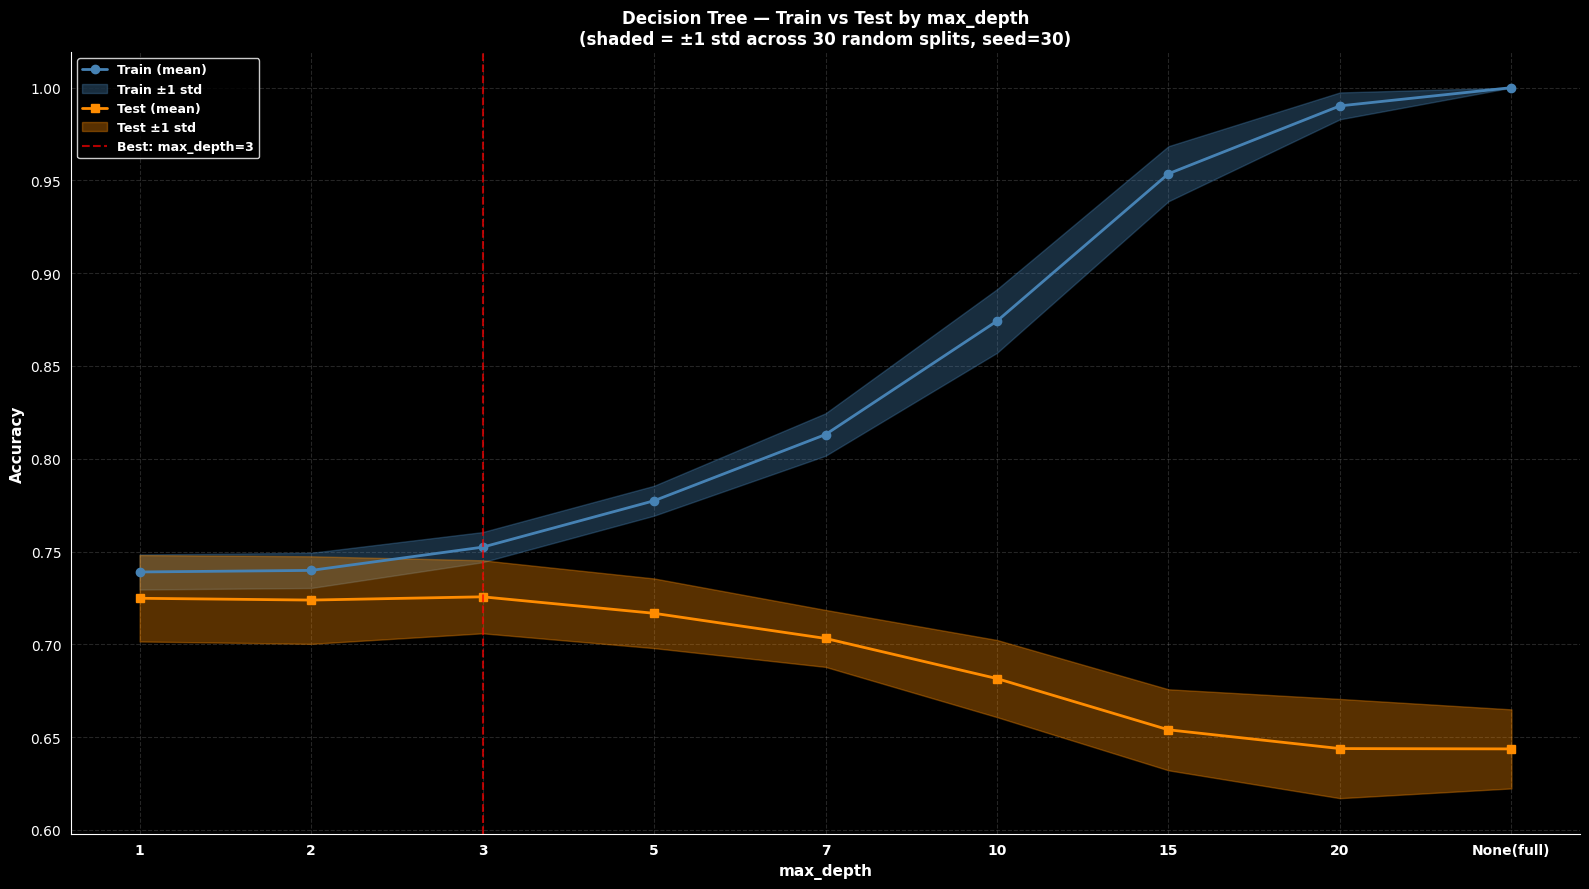

In [ ]:
dt_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor), ('dt', DecisionTreeClassifier(random_state=42))]),
    {'dt__max_depth': [None,3,5,7,10,15,20], 'dt__min_samples_split': [2,5,10,20],
     'dt__min_samples_leaf': [1,2,4,8], 'dt__criterion': ['gini','entropy']},
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
dt_grid.fit(X_train, y_train)
dt_best      = dt_grid.best_estimator_
dt_test_pred = dt_best.predict(X_test)

print(f"Best params : {dt_grid.best_params_}")
print(f"CV Score    : {dt_grid.best_score_:.4f}")

depth_values = [1,2,3,5,7,10,15,20,None]
depth_labels = [str(d) if d is not None else 'None(full)' for d in depth_values]
dt_mc_train, dt_mc_test = mc_sweep(
    lambda d: Pipeline([('preprocessor', preprocessor),
                        ('dt', DecisionTreeClassifier(max_depth=d, random_state=42))]),
    depth_values
)
best_depth = dt_grid.best_params_['dt__max_depth']
best_depth_idx = list(depth_values).index(best_depth)
dt_mc_train_mean = dt_mc_train[best_depth_idx].mean()
dt_mc_test_mean  = dt_mc_test[best_depth_idx].mean()
print(f"\nMC Train (at best max_depth={best_depth}): {dt_mc_train_mean:.4f}")
print(f"MC Test  (at best max_depth={best_depth}): {dt_mc_test_mean:.4f}")
print(f"MC Gap                                   : {abs(dt_mc_train_mean - dt_mc_test_mean):.4f}")
plot_mc_bands(depth_values, dt_mc_train, dt_mc_test, xlabel='max_depth',
              title='Decision Tree — Train vs Test by max_depth',
              best_val=best_depth, best_label=f'max_depth={best_depth}', x_labels=depth_labels)


### MC Final Score + Confusion Matrix

Decision Tree MC (30 splits, seed=30): 0.7256 ± 0.0197


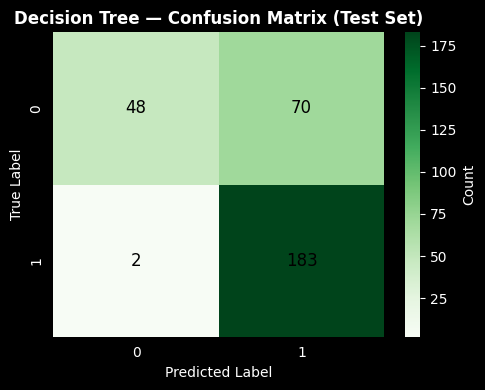


Confusion Matrix Metrics:
  TP:  183  TN:   48  FP:   70  FN:    2
  Accuracy : 0.7624
  Precision: 0.7233
  Recall   : 0.9892
  F1 Score : 0.8356


In [ ]:
dt_mc_mean, dt_mc_std = mc_final_score(dt_best, 'Decision Tree')
plot_confusion(y_test, dt_test_pred, 'Decision Tree — Confusion Matrix (Test Set)', cmap='Greens')
print("\nConfusion Matrix Metrics:")
print_cm_metrics(y_test, dt_test_pred)


---
## 4. Random Forest

### Part 1 — Base Model

In [ ]:
rf_base = Pipeline([('preprocessor', preprocessor),
                   ('rf', RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1))])
rf_base.fit(X_train, y_train)
rf_base_train_acc = rf_base.score(X_train, y_train)
rf_base_test_acc  = rf_base.score(X_test,  y_test)
print(f"RF BASE (n=100)  Train: {rf_base_train_acc:.4f}  Test: {rf_base_test_acc:.4f}")


RF BASE (n=100)  Train: 1.0000  Test: 0.7822


### Part 2 — GridSearchCV + MC Sweep

Best params : {'rf__max_depth': 5, 'rf__max_features': 'sqrt', 'rf__n_estimators': 300}
CV Score    : 0.7322

MC Train (at best n=300): 0.7811
MC Test  (at best n=300): 0.7444
MC Gap                          : 0.0367


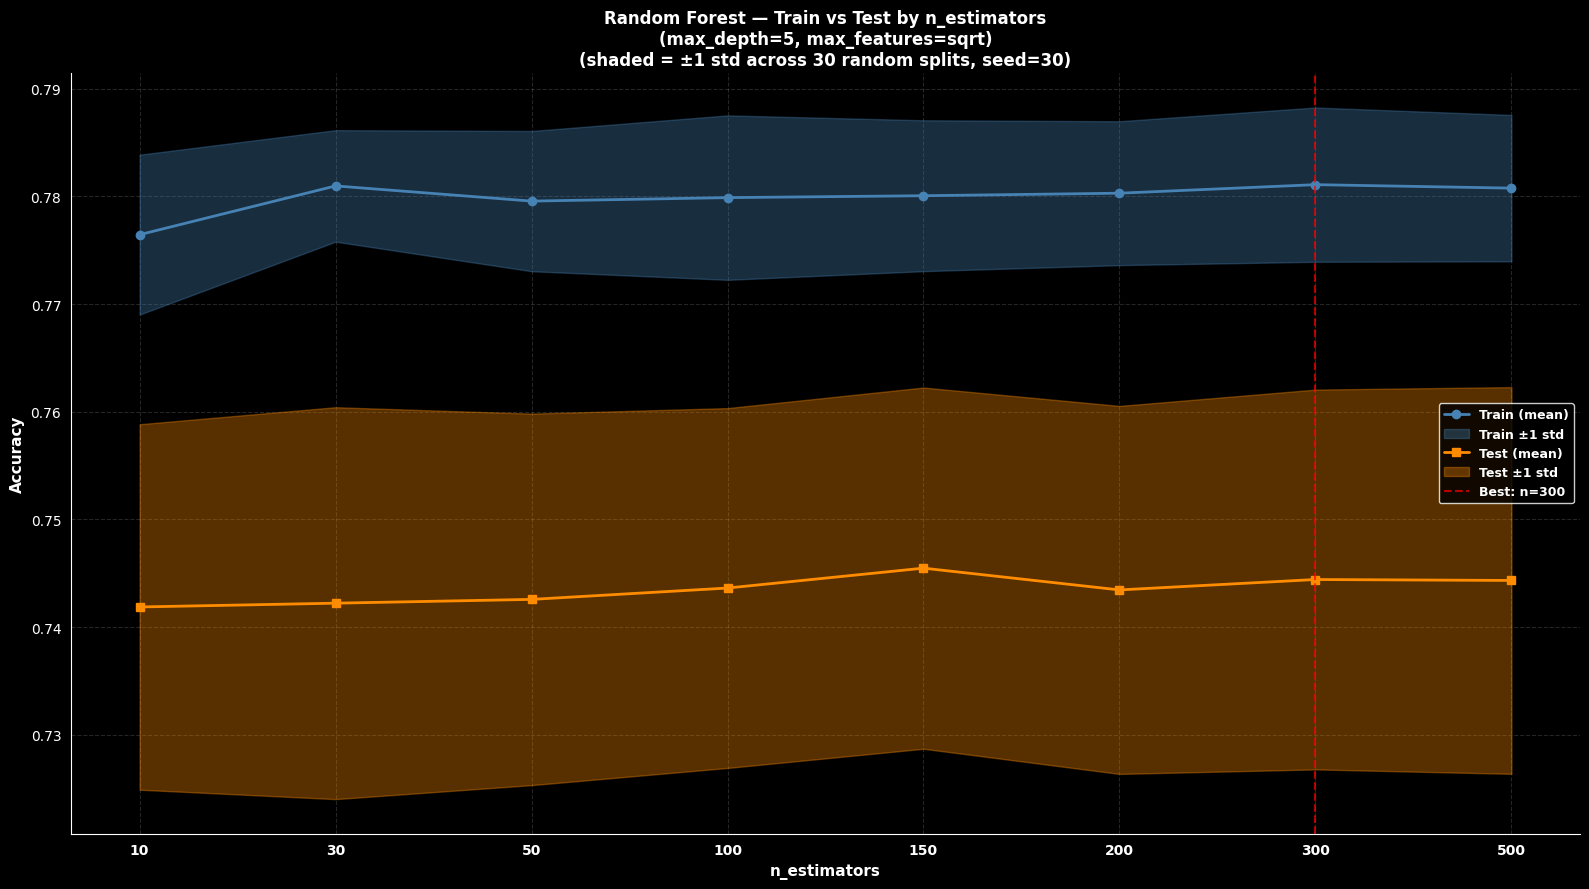

In [ ]:
rf_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('rf', RandomForestClassifier(random_state=42, n_jobs=-1))]),
    {'rf__n_estimators': [100,200,300], 'rf__max_depth': [None,5,8,10,20],
     'rf__max_features': ['sqrt','log2']},
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
rf_grid.fit(X_train, y_train)
rf_best      = rf_grid.best_estimator_
rf_test_pred = rf_best.predict(X_test)

print(f"Best params : {rf_grid.best_params_}")
print(f"CV Score    : {rf_grid.best_score_:.4f}")

best_depth_rf = rf_grid.best_params_['rf__max_depth']
best_feat_rf  = rf_grid.best_params_['rf__max_features']
n_values      = [10,30,50,100,150,200,300,500]
rf_mc_train, rf_mc_test = mc_sweep(
    lambda n: Pipeline([('preprocessor', preprocessor),
                        ('rf', RandomForestClassifier(n_estimators=n, max_depth=best_depth_rf,
                                                      max_features=best_feat_rf,
                                                      random_state=42, n_jobs=-1))]),
    n_values
)
best_n_rf = rf_grid.best_params_['rf__n_estimators']
rf_mc_train_mean = rf_mc_train[n_values.index(best_n_rf)].mean()
rf_mc_test_mean  = rf_mc_test[n_values.index(best_n_rf)].mean()
print(f"\nMC Train (at best n={best_n_rf}): {rf_mc_train_mean:.4f}")
print(f"MC Test  (at best n={best_n_rf}): {rf_mc_test_mean:.4f}")
print(f"MC Gap                          : {abs(rf_mc_train_mean - rf_mc_test_mean):.4f}")
plot_mc_bands(n_values, rf_mc_train, rf_mc_test, xlabel='n_estimators',
              title=f'Random Forest — Train vs Test by n_estimators\n(max_depth={best_depth_rf}, max_features={best_feat_rf})',
              best_val=best_n_rf, best_label=f'n={best_n_rf}')


### MC Final Score + Confusion Matrix

Random Forest MC (30 splits, seed=30): 0.7444 ± 0.0176


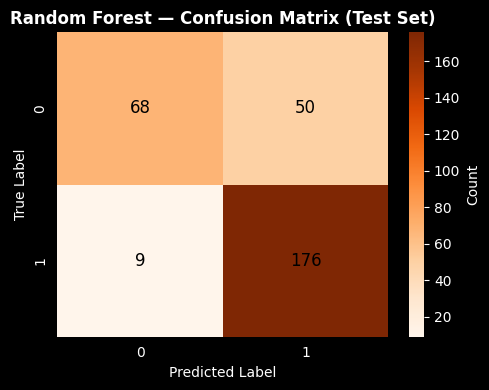


Confusion Matrix Metrics:
  TP:  176  TN:   68  FP:   50  FN:    9
  Accuracy : 0.8053
  Precision: 0.7788
  Recall   : 0.9514
  F1 Score : 0.8564


In [ ]:
rf_mc_mean, rf_mc_std = mc_final_score(rf_best, 'Random Forest')
plot_confusion(y_test, rf_test_pred, 'Random Forest — Confusion Matrix (Test Set)', cmap='Oranges')
print("\nConfusion Matrix Metrics:")
print_cm_metrics(y_test, rf_test_pred)


### Feature Importance — Decision Tree & Random Forest

/tmp/ipykernel_1047/3093850444.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df_i['feature'], fontsize=9, fontweight='bold', color='white')


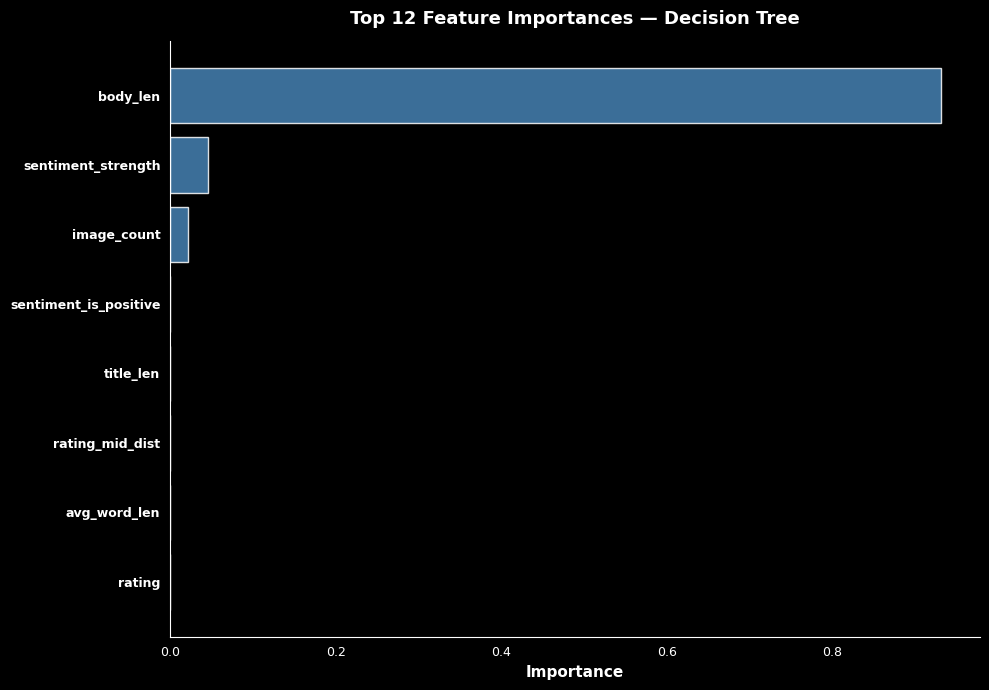

/tmp/ipykernel_1047/3093850444.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(df_i['feature'], fontsize=9, fontweight='bold', color='white')


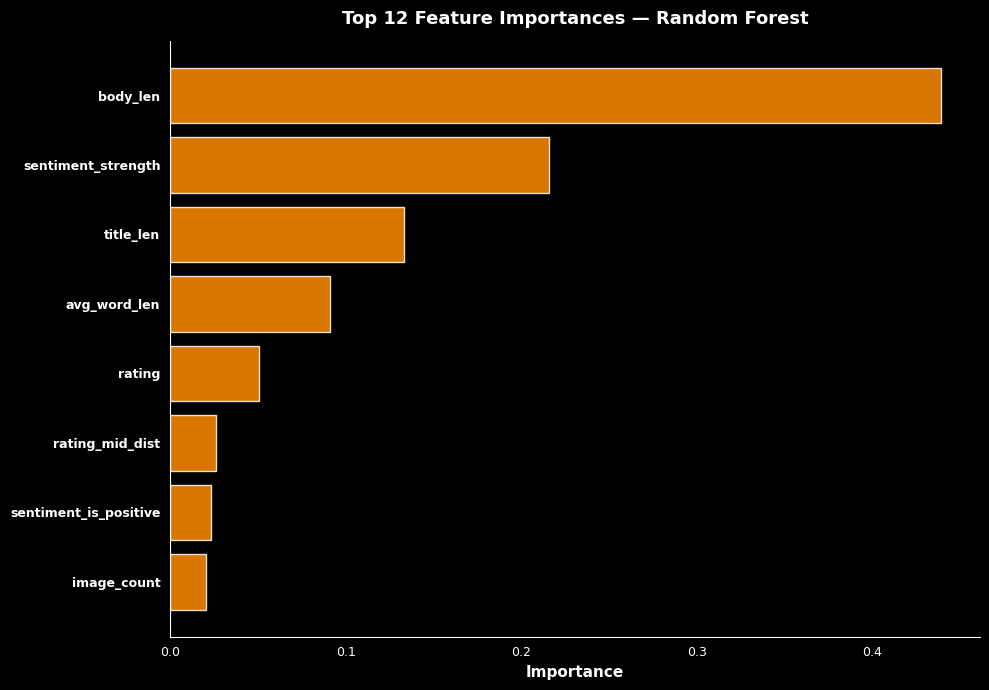

In [ ]:
if categorical_cols:
    prep_fitted = dt_best.named_steps['preprocessor']
    cat_feats   = list(prep_fitted.named_transformers_['cat'].get_feature_names_out(categorical_cols))
    all_feats   = numerical_cols + cat_feats
else:
    all_feats = numerical_cols

top_n = 12
dt_imp  = get_top_imp(dt_best.named_steps['dt'].feature_importances_)
rf_imp  = get_top_imp(rf_best.named_steps['rf'].feature_importances_)

for df_i, name, col in [(dt_imp, 'Decision Tree', 'steelblue'),
                         (rf_imp, 'Random Forest', 'darkorange')]:
    fig, ax = plt.subplots(figsize=(10, 7), facecolor='black')
    ax.set_facecolor('black')
    ax.barh(df_i['feature'], df_i['importance'], color=col, alpha=0.85)
    ax.set_title(f'Top {top_n} Feature Importances — {name}',
                 fontsize=13, fontweight='bold', color='white', pad=12)
    ax.set_xlabel('Importance', fontsize=11, fontweight='bold', color='white')
    ax.tick_params(axis='both', colors='white', labelsize=9)
    ax.set_yticklabels(df_i['feature'], fontsize=9, fontweight='bold', color='white')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')
    ax.grid(False)
    plt.tight_layout()
    plt.show()


---
## 5. XGBoost

### Part 1 — Base Model

In [ ]:
xgb_base = Pipeline([('preprocessor', preprocessor),
                    ('xgb', XGBClassifier(n_estimators=100, learning_rate=0.1, max_depth=3,
                                          random_state=42, eval_metric='logloss', verbosity=0))])
xgb_base.fit(X_train, y_train)
xgb_base_train_acc = xgb_base.score(X_train, y_train)
xgb_base_test_acc  = xgb_base.score(X_test,  y_test)
print(f"XGB BASE  Train: {xgb_base_train_acc:.4f}  Test: {xgb_base_test_acc:.4f}")


XGB BASE  Train: 0.7843  Test: 0.7921


### Part 2 — GridSearchCV + MC Sweep

Best params : {'xgb__learning_rate': 0.02, 'xgb__max_depth': 3, 'xgb__n_estimators': 400}
CV Score    : 0.7413

MC Train (at best n=400): 0.7935
MC Test  (at best n=400): 0.7441
MC Gap                           : 0.0494


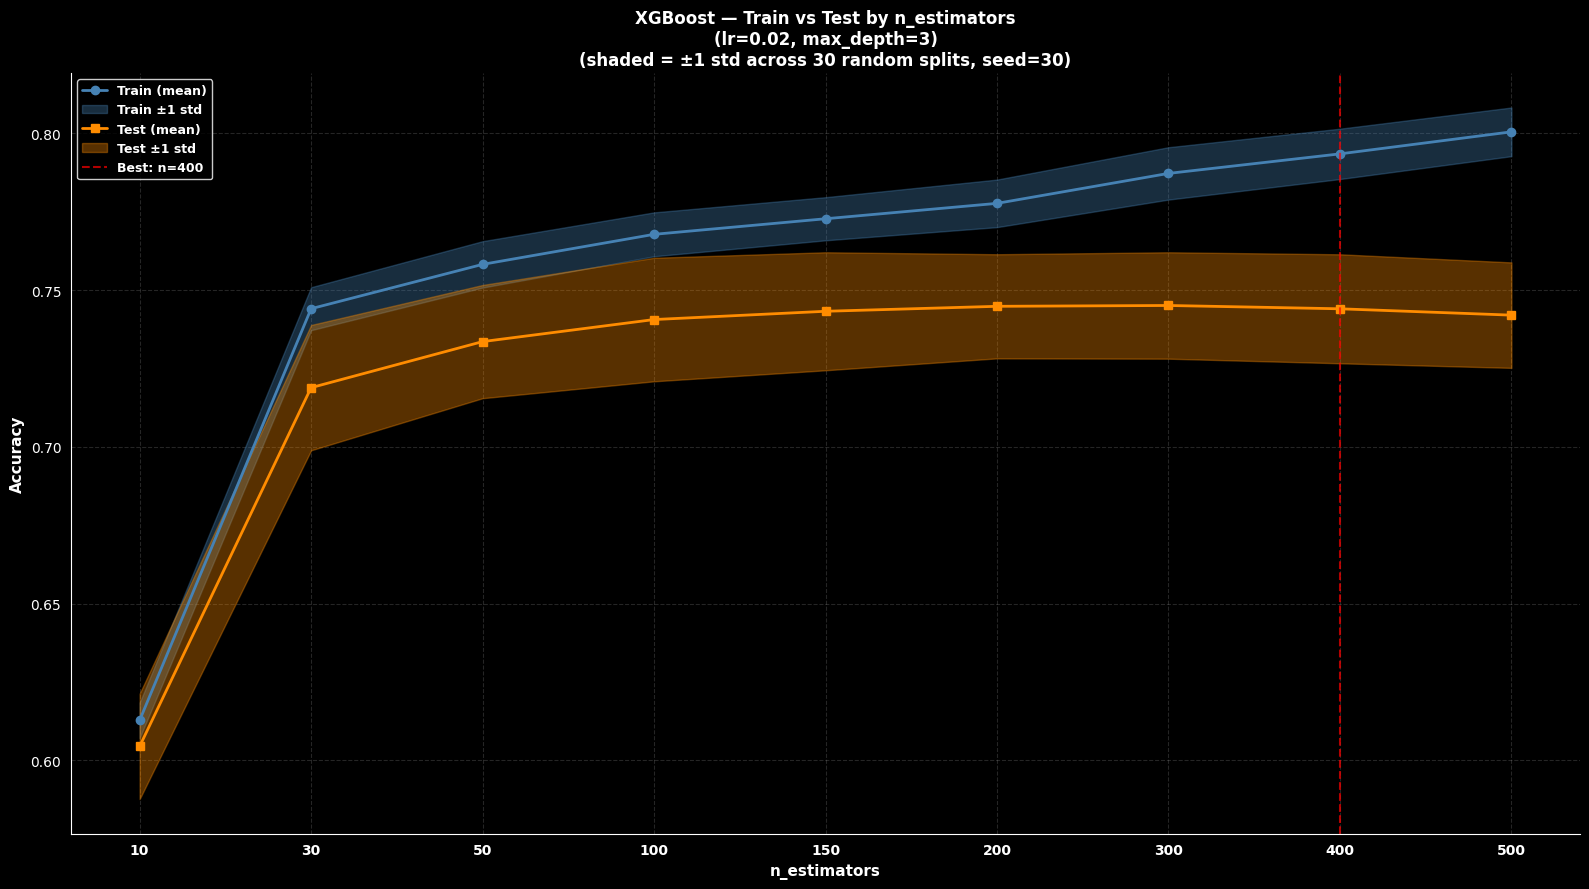

In [ ]:
xgb_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('xgb', XGBClassifier(random_state=42, eval_metric='logloss', verbosity=0))]),
    {'xgb__n_estimators': [200,400,600,800], 'xgb__learning_rate': [0.005,0.01,0.02,0.05],
     'xgb__max_depth': [2,3,4,5]},
    cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
xgb_grid.fit(X_train, y_train)
xgb_best      = xgb_grid.best_estimator_
xgb_test_pred = xgb_best.predict(X_test)

print(f"Best params : {xgb_grid.best_params_}")
print(f"CV Score    : {xgb_grid.best_score_:.4f}")

best_lr_xgb    = xgb_grid.best_params_['xgb__learning_rate']
best_depth_xgb = xgb_grid.best_params_['xgb__max_depth']
n_values_xgb = [10,30,50,100,150,200,300,400,500]
xgb_mc_train, xgb_mc_test = mc_sweep(
    lambda n: Pipeline([('preprocessor', preprocessor),
                        ('xgb', XGBClassifier(n_estimators=n, learning_rate=best_lr_xgb,
                                              max_depth=best_depth_xgb, random_state=42,
                                              eval_metric='logloss', verbosity=0))]),
    n_values_xgb
)
best_n_xgb = xgb_grid.best_params_['xgb__n_estimators']
xgb_mc_train_mean = xgb_mc_train[n_values_xgb.index(best_n_xgb)].mean()
xgb_mc_test_mean  = xgb_mc_test[n_values_xgb.index(best_n_xgb)].mean()
print(f"\nMC Train (at best n={best_n_xgb}): {xgb_mc_train_mean:.4f}")
print(f"MC Test  (at best n={best_n_xgb}): {xgb_mc_test_mean:.4f}")
print(f"MC Gap                           : {abs(xgb_mc_train_mean - xgb_mc_test_mean):.4f}")
plot_mc_bands(n_values_xgb, xgb_mc_train, xgb_mc_test, xlabel='n_estimators',
              title=f'XGBoost — Train vs Test by n_estimators\n(lr={best_lr_xgb}, max_depth={best_depth_xgb})',
              best_val=best_n_xgb, best_label=f'n={best_n_xgb}')


### MC Final Score + Confusion Matrix + Feature Importance

XGBoost MC (30 splits, seed=30): 0.7441 ± 0.0174


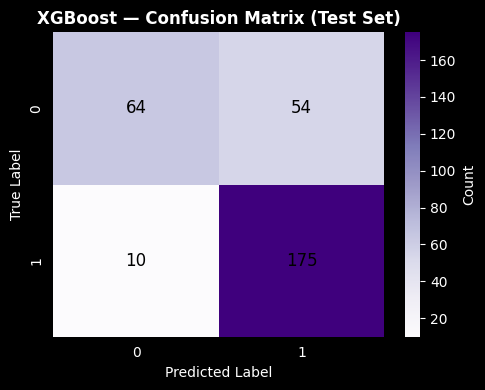


Confusion Matrix Metrics:
  TP:  175  TN:   64  FP:   54  FN:   10
  Accuracy : 0.7888
  Precision: 0.7642
  Recall   : 0.9459
  F1 Score : 0.8454


/tmp/ipykernel_1047/3220027009.py:13: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(xgb_imp['feature'], fontsize=9, fontweight='bold', color='white')


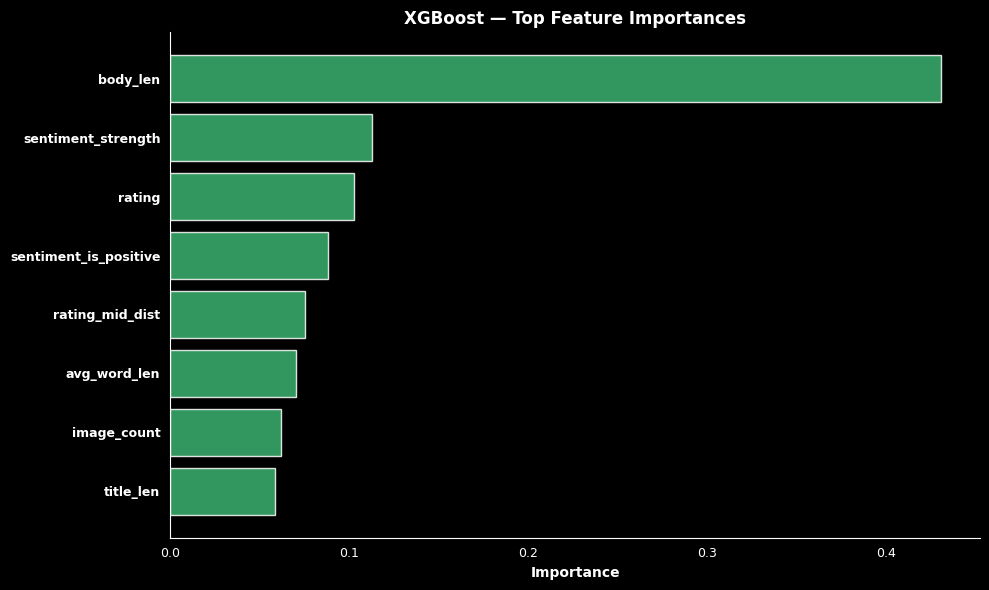

In [ ]:
xgb_mc_mean, xgb_mc_std = mc_final_score(xgb_best, 'XGBoost')
plot_confusion(y_test, xgb_test_pred, 'XGBoost — Confusion Matrix (Test Set)', cmap='Purples')
print("\nConfusion Matrix Metrics:")
print_cm_metrics(y_test, xgb_test_pred)

xgb_imp = get_top_imp(xgb_best.named_steps['xgb'].feature_importances_)
fig, ax = plt.subplots(figsize=(10, 6), facecolor='black')
ax.set_facecolor('black')
ax.barh(xgb_imp['feature'], xgb_imp['importance'], color='mediumseagreen', alpha=0.85)
ax.set_title('XGBoost — Top Feature Importances', fontweight='bold', color='white')
ax.set_xlabel('Importance', color='white', fontweight='bold')
ax.tick_params(axis='both', colors='white', labelsize=9)
ax.set_yticklabels(xgb_imp['feature'], fontsize=9, fontweight='bold', color='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
ax.grid(False)
plt.tight_layout()
plt.show()


---
## 6. Logistic Regression

### 6.1 L1 — Part 1 — Base Model (C=1.0)

In [ ]:
l1_base = Pipeline([('preprocessor', preprocessor),
                   ('lr', LogisticRegression(penalty='l1', solver='liblinear',
                                             C=1.0, random_state=42, max_iter=1000))])
l1_base.fit(X_train, y_train)
l1_base_train_acc = l1_base.score(X_train, y_train)
l1_base_test_acc  = l1_base.score(X_test,  y_test)
l1_base_roc = roc_auc_score(y_test, l1_base.predict_proba(X_test)[:,1])
n_nonzero_base = np.count_nonzero(l1_base.named_steps['lr'].coef_[0])
print(f"L1 BASE (C=1.0)  Train: {l1_base_train_acc:.4f}  Test: {l1_base_test_acc:.4f}  ROC-AUC: {l1_base_roc:.4f}")
print(f"Features kept (non-zero): {n_nonzero_base} / {len(l1_base.named_steps['lr'].coef_[0])}")


L1 BASE (C=1.0)  Train: 0.7298  Test: 0.7855  ROC-AUC: 0.8132
Features kept (non-zero): 8 / 8


### 6.1 L1 — Part 2 — GridSearchCV + MC Sweep

Best C      : 1
CV Score    : 0.7289
ROC-AUC     : 0.8132
Features kept: 8

MC Train (at best C=1): 0.7445
MC Test  (at best C=1): 0.7408
MC Gap                          : 0.0037


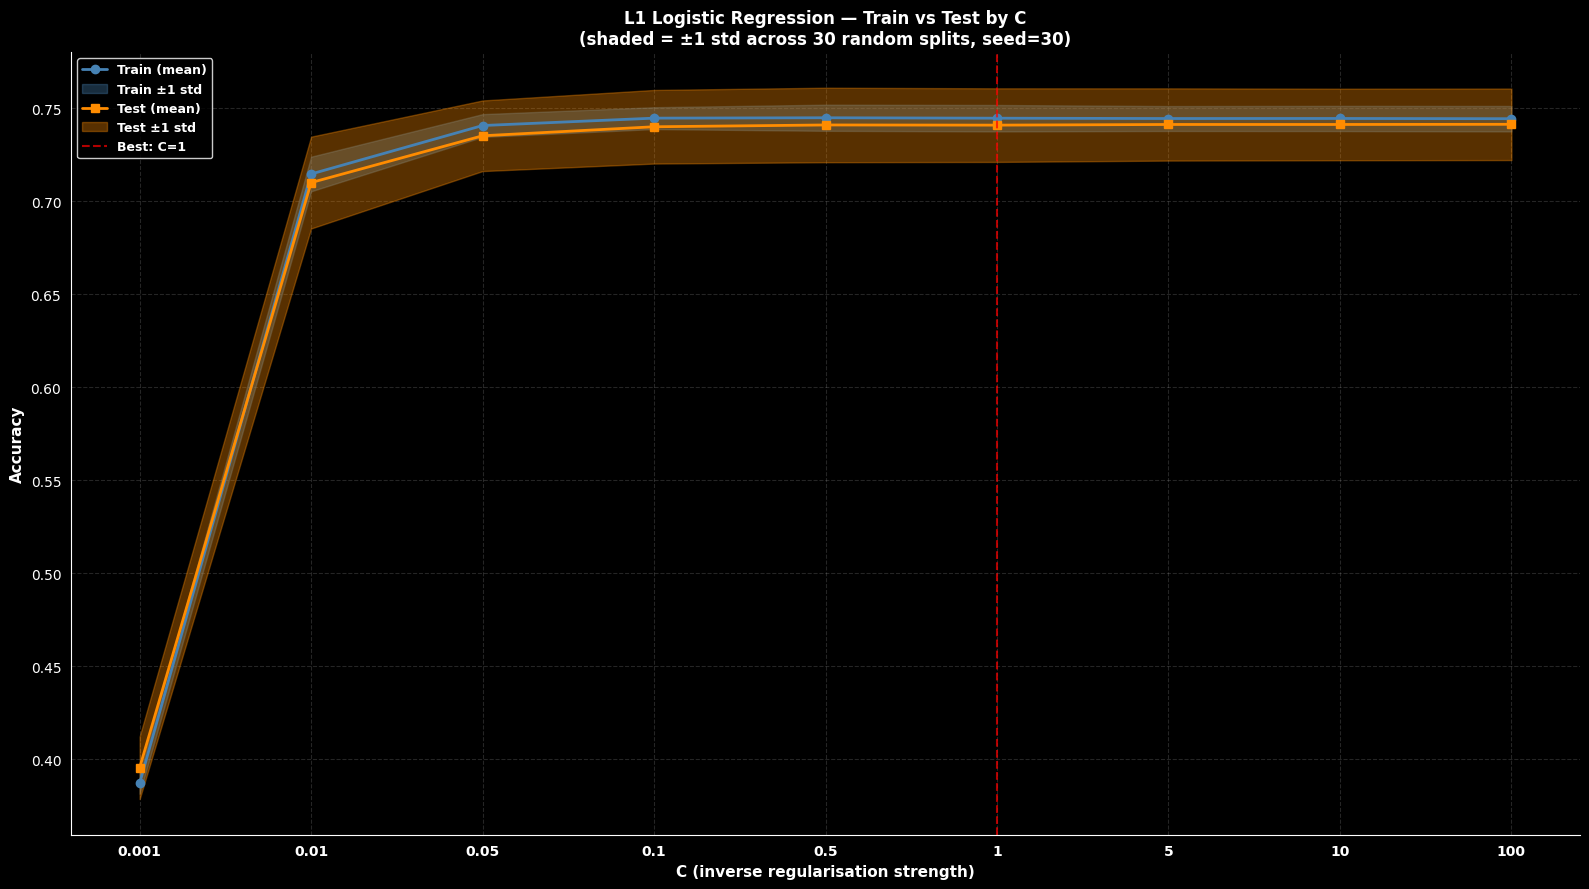

In [ ]:
c_values_lr = [0.001, 0.01, 0.05, 0.1, 0.5, 1, 5, 10, 100]

l1_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('lr', LogisticRegression(penalty='l1', solver='liblinear',
                                        random_state=42, max_iter=1000))]),
    {'lr__C': c_values_lr}, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
l1_grid.fit(X_train, y_train)
l1_best      = l1_grid.best_estimator_
l1_test_pred = l1_best.predict(X_test)
l1_roc       = roc_auc_score(y_test, l1_best.predict_proba(X_test)[:,1])
l1_nonzero   = np.count_nonzero(l1_best.named_steps['lr'].coef_[0])

print(f"Best C      : {l1_grid.best_params_['lr__C']}")
print(f"CV Score    : {l1_grid.best_score_:.4f}")
print(f"ROC-AUC     : {l1_roc:.4f}")
print(f"Features kept: {l1_nonzero}")

l1_mc_train, l1_mc_test = mc_sweep(
    lambda c: Pipeline([('preprocessor', preprocessor),
                        ('lr', LogisticRegression(penalty='l1', solver='liblinear',
                                                   C=c, random_state=42, max_iter=1000))]),
    c_values_lr
)
best_c_l1 = l1_grid.best_params_['lr__C']
l1_mc_train_mean = l1_mc_train[c_values_lr.index(best_c_l1)].mean()
l1_mc_test_mean  = l1_mc_test[c_values_lr.index(best_c_l1)].mean()
print(f"\nMC Train (at best C={best_c_l1}): {l1_mc_train_mean:.4f}")
print(f"MC Test  (at best C={best_c_l1}): {l1_mc_test_mean:.4f}")
print(f"MC Gap                          : {abs(l1_mc_train_mean - l1_mc_test_mean):.4f}")
plot_mc_bands(c_values_lr, l1_mc_train, l1_mc_test,
              xlabel='C (inverse regularisation strength)',
              title='L1 Logistic Regression — Train vs Test by C',
              best_val=best_c_l1, best_label=f'C={best_c_l1}',
              x_labels=[str(c) for c in c_values_lr])


### 6.1 L1 — MC Final Score + Confusion Matrix

LR-L1 MC (30 splits, seed=30): 0.7408 ± 0.0198


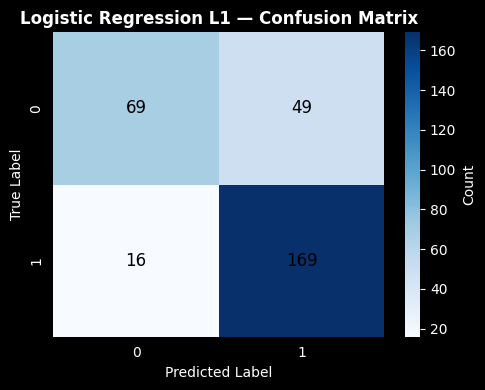


Confusion Matrix Metrics:
  TP:  169  TN:   69  FP:   49  FN:   16
  Accuracy : 0.7855
  Precision: 0.7752
  Recall   : 0.9135
  F1 Score : 0.8387


In [ ]:
l1_mc_mean, l1_mc_std = mc_final_score(l1_best, 'LR-L1')
plot_confusion(y_test, l1_test_pred, 'Logistic Regression L1 — Confusion Matrix', cmap='Blues')
print("\nConfusion Matrix Metrics:")
print_cm_metrics(y_test, l1_test_pred)


### 6.2 L2 — Part 1 — Base Model (C=1.0)

In [ ]:
l2_base = Pipeline([('preprocessor', preprocessor),
                   ('lr', LogisticRegression(penalty='l2', solver='lbfgs',
                                             C=1.0, random_state=42, max_iter=1000))])
l2_base.fit(X_train, y_train)
l2_base_train_acc = l2_base.score(X_train, y_train)
l2_base_test_acc  = l2_base.score(X_test,  y_test)
l2_base_roc = roc_auc_score(y_test, l2_base.predict_proba(X_test)[:,1])
print(f"L2 BASE (C=1.0)  Train: {l2_base_train_acc:.4f}  Test: {l2_base_test_acc:.4f}  ROC-AUC: {l2_base_roc:.4f}")


L2 BASE (C=1.0)  Train: 0.7306  Test: 0.7855  ROC-AUC: 0.8123


### 6.2 L2 — Part 2 — GridSearchCV + MC Sweep

Best C      : 0.1
CV Score    : 0.7372
ROC-AUC     : 0.8121

MC Train (at best C=0.1): 0.7466
MC Test  (at best C=0.1): 0.7424
MC Gap                          : 0.0042


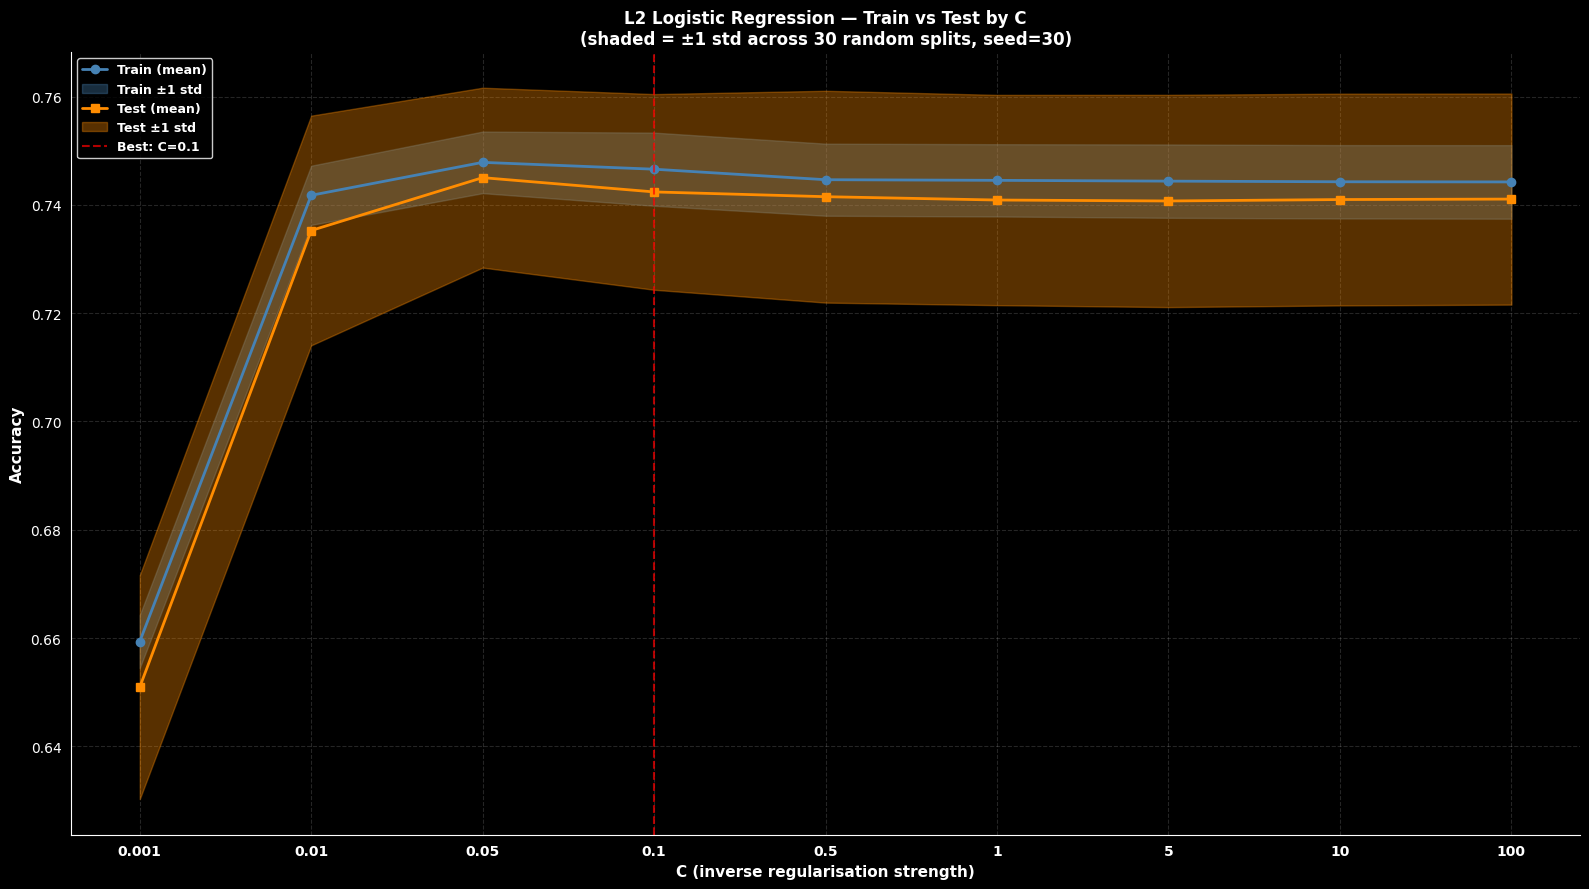

In [ ]:
l2_grid = GridSearchCV(
    Pipeline([('preprocessor', preprocessor),
              ('lr', LogisticRegression(penalty='l2', solver='lbfgs',
                                        random_state=42, max_iter=1000))]),
    {'lr__C': c_values_lr}, cv=5, scoring='accuracy', n_jobs=-1, verbose=0
)
l2_grid.fit(X_train, y_train)
l2_best      = l2_grid.best_estimator_
l2_test_pred = l2_best.predict(X_test)
l2_roc       = roc_auc_score(y_test, l2_best.predict_proba(X_test)[:,1])

print(f"Best C      : {l2_grid.best_params_['lr__C']}")
print(f"CV Score    : {l2_grid.best_score_:.4f}")
print(f"ROC-AUC     : {l2_roc:.4f}")

l2_mc_train, l2_mc_test = mc_sweep(
    lambda c: Pipeline([('preprocessor', preprocessor),
                        ('lr', LogisticRegression(penalty='l2', solver='lbfgs',
                                                   C=c, random_state=42, max_iter=1000))]),
    c_values_lr
)
best_c_l2 = l2_grid.best_params_['lr__C']
l2_mc_train_mean = l2_mc_train[c_values_lr.index(best_c_l2)].mean()
l2_mc_test_mean  = l2_mc_test[c_values_lr.index(best_c_l2)].mean()
print(f"\nMC Train (at best C={best_c_l2}): {l2_mc_train_mean:.4f}")
print(f"MC Test  (at best C={best_c_l2}): {l2_mc_test_mean:.4f}")
print(f"MC Gap                          : {abs(l2_mc_train_mean - l2_mc_test_mean):.4f}")
plot_mc_bands(c_values_lr, l2_mc_train, l2_mc_test,
              xlabel='C (inverse regularisation strength)',
              title='L2 Logistic Regression — Train vs Test by C',
              best_val=best_c_l2, best_label=f'C={best_c_l2}',
              x_labels=[str(c) for c in c_values_lr])


### 6.2 L2 — Diagnostic

In [ ]:
# Diagnostic — check if it's regularisation causing train < test
print("Class balance check:")
print(f"  Full dataset : {y.mean():.3f}")
print(f"  Train split  : {y_train.mean():.3f}")
print(f"  Test split   : {y_test.mean():.3f}")

print("\nUnregularised L2 (C=1000)")
check = Pipeline([('preprocessor', preprocessor),
                  ('lr', LogisticRegression(penalty='l2', solver='lbfgs',
                                            C=1000, random_state=42, max_iter=1000))])
check.fit(X_train, y_train)
print(f"  Train: {check.score(X_train, y_train):.4f}  Test: {check.score(X_test, y_test):.4f}")


Class balance check:
  Full dataset : 0.611
  Train split  : 0.611
  Test split   : 0.611

Unregularised L2 (C=1000)
  Train: 0.7298  Test: 0.7822


### 6.2 L2 — MC Final Score + Confusion Matrix

LR-L2 MC (30 splits, seed=30): 0.7424 ± 0.0181


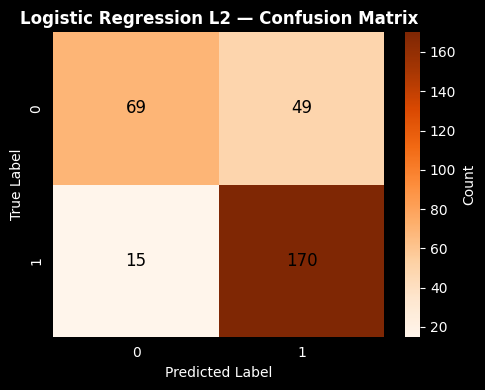


Confusion Matrix Metrics:
  TP:  170  TN:   69  FP:   49  FN:   15
  Accuracy : 0.7888
  Precision: 0.7763
  Recall   : 0.9189
  F1 Score : 0.8416


In [ ]:
l2_mc_mean, l2_mc_std = mc_final_score(l2_best, 'LR-L2')
plot_confusion(y_test, l2_test_pred, 'Logistic Regression L2 — Confusion Matrix', cmap='Oranges')
print("\nConfusion Matrix Metrics:")
print_cm_metrics(y_test, l2_test_pred)


### 6.3 L1 vs L2 — ROC Curves + Coefficient Comparison

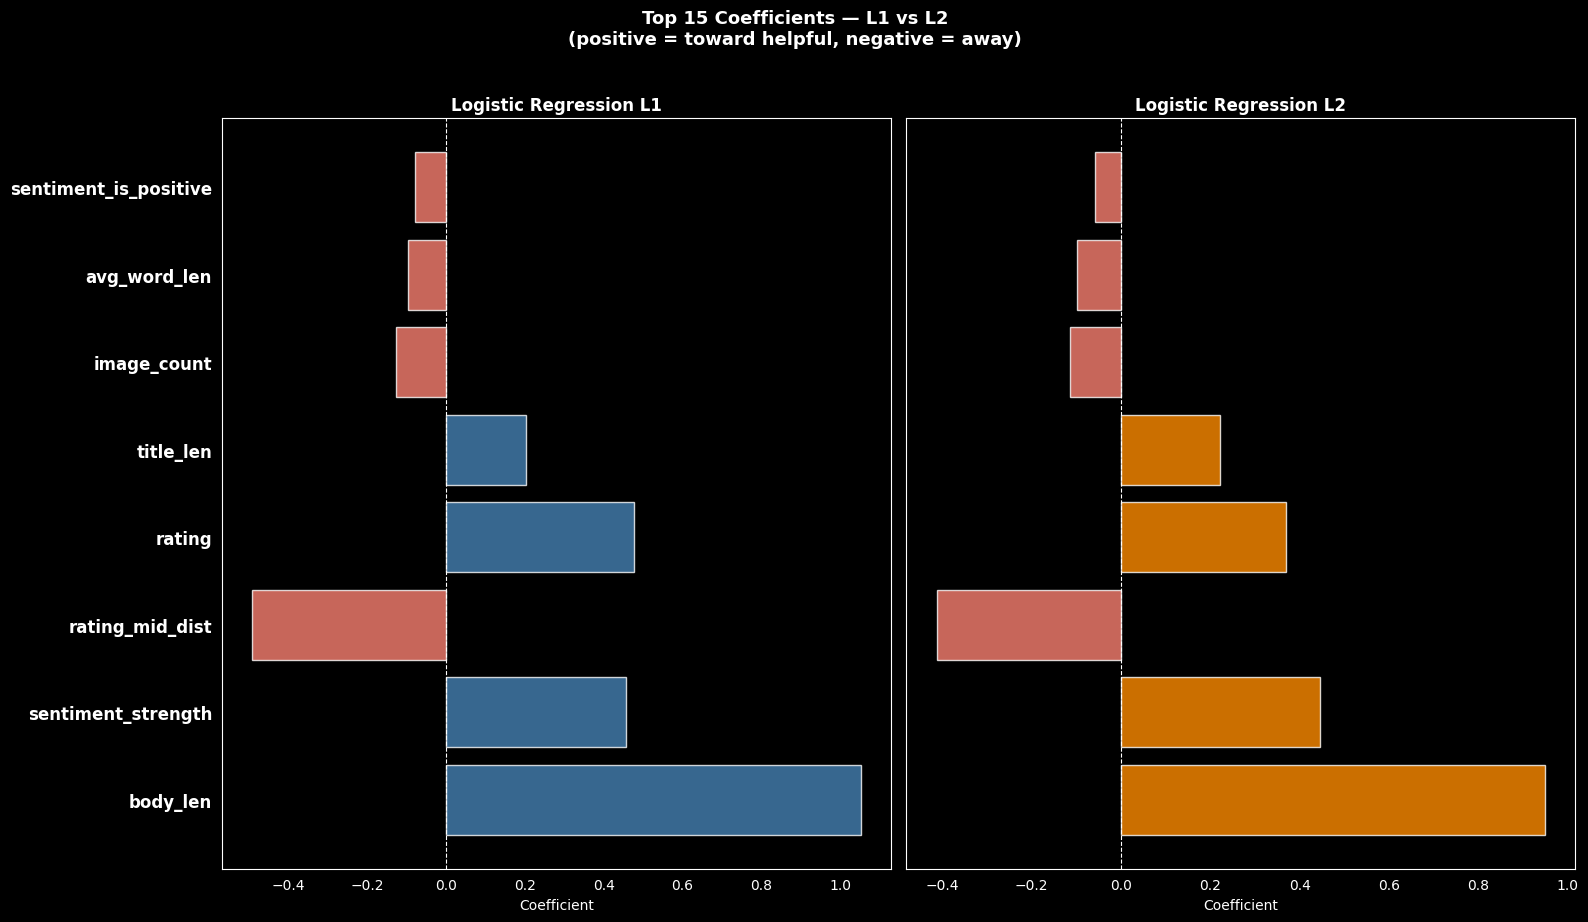

L1 zeroed out: 0 / 8 features


In [ ]:
# Coefficient comparison
if categorical_cols:
    prep_fitted = l1_best.named_steps['preprocessor']
    cat_feats   = list(prep_fitted.named_transformers_['cat'].get_feature_names_out(categorical_cols))
    lr_feats    = numerical_cols + cat_feats
else:
    lr_feats = numerical_cols

l1_coefs = l1_best.named_steps['lr'].coef_[0]
l2_coefs = l2_best.named_steps['lr'].coef_[0]
coef_df  = pd.DataFrame({'feature': lr_feats, 'L1': l1_coefs, 'L2': l2_coefs}) \
             .set_index('feature').reindex(
                 pd.DataFrame({'feature': lr_feats, 'abs_l2': np.abs(l2_coefs)})
                 .nlargest(15,'abs_l2')['feature'])

fig, axes = plt.subplots(1, 2, figsize=(16, 9), sharey=True)
for ax, col, color in zip(axes, ['L1','L2'], ['steelblue','darkorange']):
    ax.grid(False)
    vals = coef_df[col]
    bar_colors = [color if v > 0 else 'salmon' for v in vals]
    ax.barh(range(len(vals)), vals, color=bar_colors, alpha=0.8)
    ax.axvline(0, color='white', lw=0.8, ls='--')
    ax.set_yticks(range(len(vals))); ax.set_yticklabels(coef_df.index, fontsize=12, fontweight='bold')
    ax.set_title(f'Logistic Regression {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Coefficient'); ax.invert_yaxis()
plt.suptitle('Top 15 Coefficients — L1 vs L2\n(positive = toward helpful, negative = away)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout(); plt.show()
print(f"L1 zeroed out: {np.sum(l1_coefs==0)} / {len(l1_coefs)} features")

---
## 7. Support Vector Machine (Linear SVM)

### 7.1 SVM L1 — Part 1 — Base Model (C=1)

In [ ]:
svm_l1_base = Pipeline([('preprocessor', preprocessor),
                       ('svm', LinearSVC(C=1, penalty='l1', loss='squared_hinge',
                                         dual=False, max_iter=10000))])
svm_l1_base.fit(X_train, y_train)
svm_l1_base_train_acc = svm_l1_base.score(X_train, y_train)
svm_l1_base_test_acc  = svm_l1_base.score(X_test,  y_test)
print(f"SVM L1 BASE (C=1)  Train: {svm_l1_base_train_acc:.4f}  Test: {svm_l1_base_test_acc:.4f}")


SVM L1 BASE (C=1)  Train: 0.7364  Test: 0.7756


### 7.1 SVM L1 — Part 2 — MC Sweep over C

Best C (by MC test mean): 0.1
MC Train (at best C)    : 0.7463
MC Test  (at best C)    : 0.7412
MC Gap                  : 0.0051


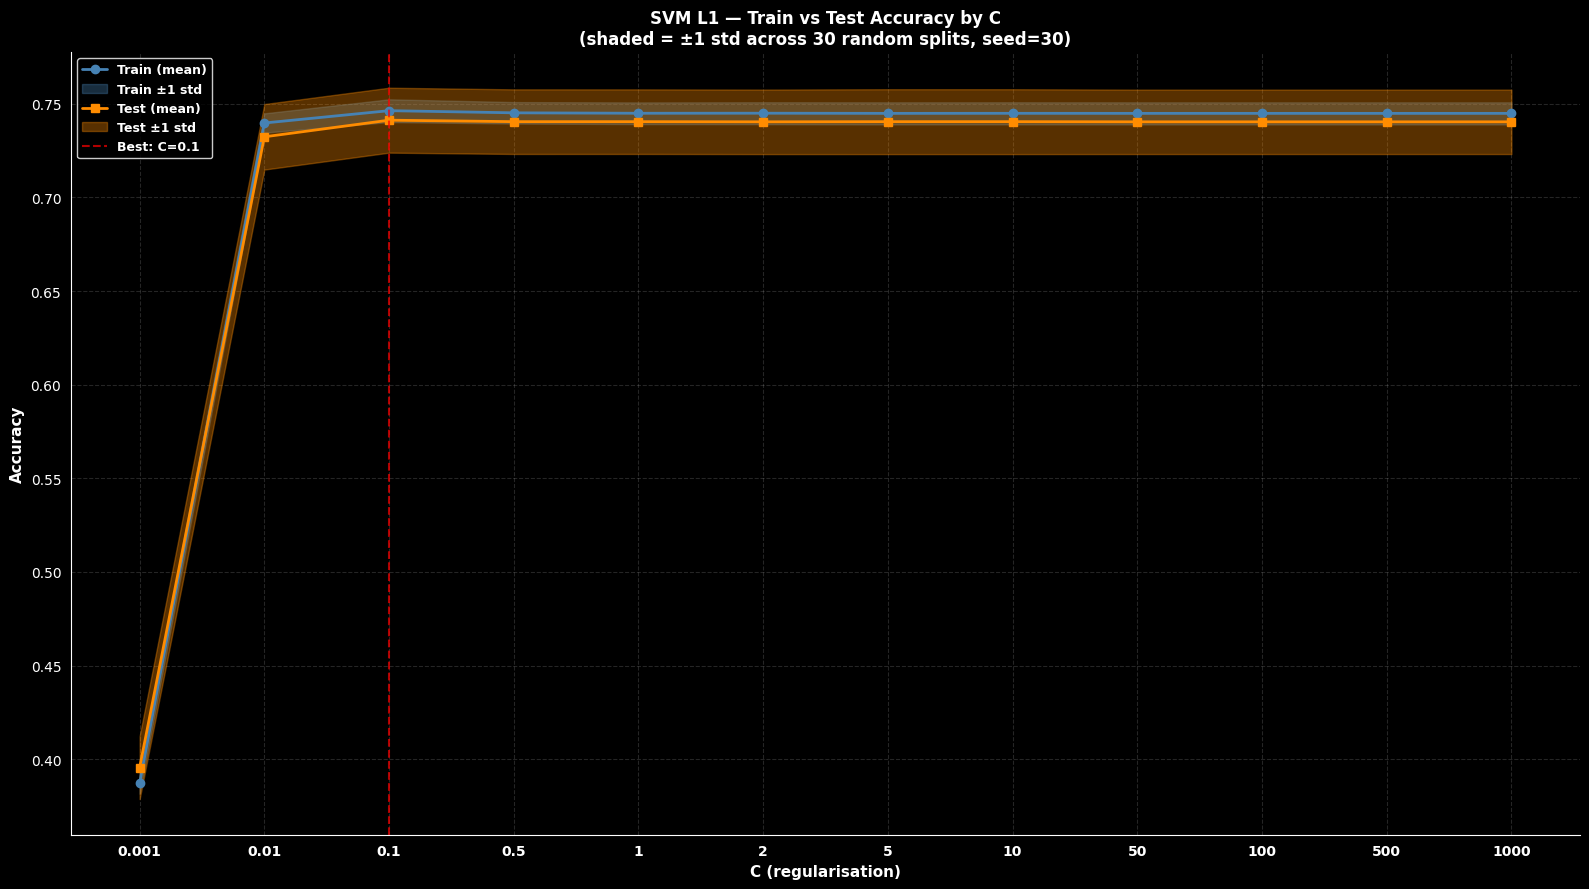

In [ ]:
C_range_svm = [0.001, 0.01, 0.1, 0.5, 1, 2, 5, 10, 50, 100, 500, 1000]

svm_l1_mc_train, svm_l1_mc_test = mc_sweep(
    lambda c: Pipeline([('preprocessor', preprocessor),
                        ('svm', LinearSVC(C=c, penalty='l1', loss='squared_hinge',
                                          dual=False, max_iter=10000))]),
    C_range_svm
)

best_c_idx_l1 = int(np.argmax(svm_l1_mc_test.mean(axis=1)))
best_c_svm_l1 = C_range_svm[best_c_idx_l1]
svm_l1_mc_train_mean = svm_l1_mc_train[best_c_idx_l1].mean()
svm_l1_mc_test_mean  = svm_l1_mc_test[best_c_idx_l1].mean()
print(f"Best C (by MC test mean): {best_c_svm_l1}")
print(f"MC Train (at best C)    : {svm_l1_mc_train_mean:.4f}")
print(f"MC Test  (at best C)    : {svm_l1_mc_test_mean:.4f}")
print(f"MC Gap                  : {abs(svm_l1_mc_train_mean - svm_l1_mc_test_mean):.4f}")

plot_mc_bands(C_range_svm, svm_l1_mc_train, svm_l1_mc_test,
              xlabel='C (regularisation)',
              title='SVM L1 — Train vs Test Accuracy by C',
              best_val=best_c_svm_l1, best_label=f'C={best_c_svm_l1}',
              x_labels=[str(c) for c in C_range_svm])


### 7.1 SVM L1 — Refit Best C + MC Final Score + Confusion Matrix

SVM L1 (C=0.1)  Train: 0.7339  Test: 0.7822
SVM-L1 MC (30 splits, seed=30): 0.7412 ± 0.0173


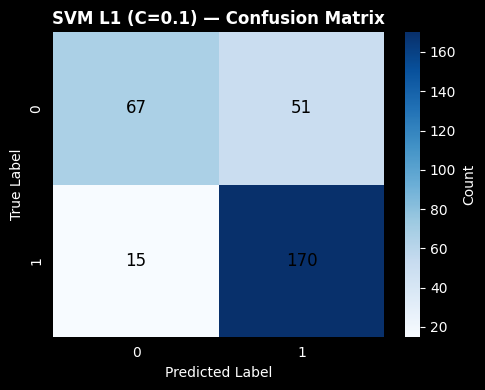


Confusion Matrix Metrics:
  TP:  170  TN:   67  FP:   51  FN:   15
  Accuracy : 0.7822
  Precision: 0.7692
  Recall   : 0.9189
  F1 Score : 0.8374


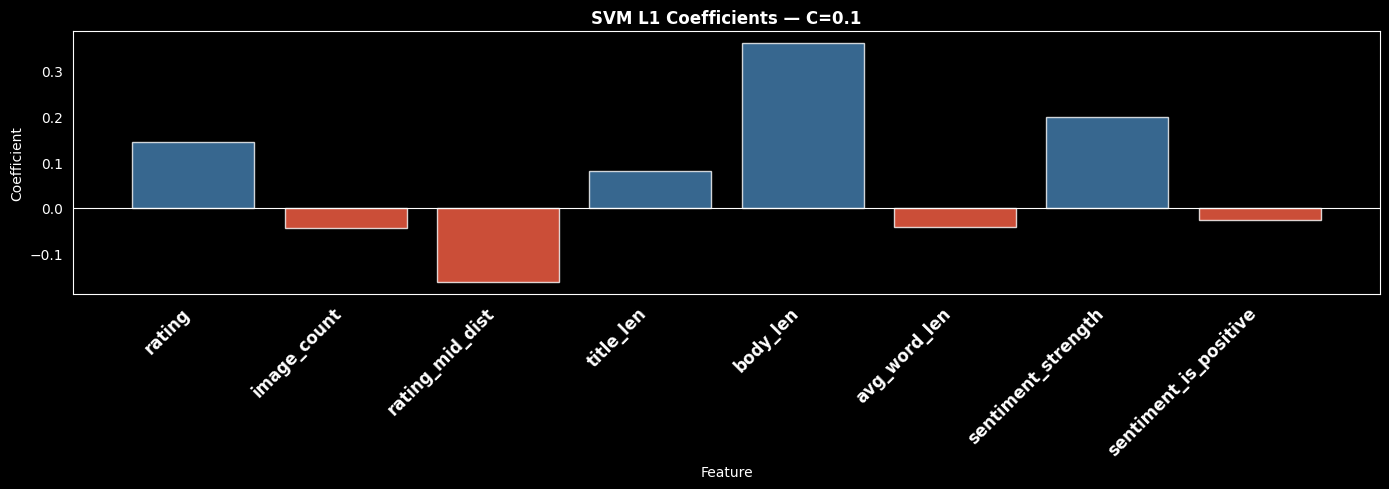

In [ ]:
svm_l1_best = Pipeline([('preprocessor', preprocessor),
                       ('svm', LinearSVC(C=best_c_svm_l1, penalty='l1', loss='squared_hinge',
                                         dual=False, max_iter=10000))])
svm_l1_best.fit(X_train, y_train)
svm_l1_test_pred = svm_l1_best.predict(X_test)
print(f"SVM L1 (C={best_c_svm_l1})  Train: {svm_l1_best.score(X_train,y_train):.4f}  Test: {svm_l1_best.score(X_test,y_test):.4f}")

svm_l1_mc_mean, svm_l1_mc_std = mc_final_score(svm_l1_best, 'SVM-L1')
plot_confusion(y_test, svm_l1_test_pred, f'SVM L1 (C={best_c_svm_l1}) — Confusion Matrix', cmap='Blues')
print("\nConfusion Matrix Metrics:")
print_cm_metrics(y_test, svm_l1_test_pred)

coef_l1_raw = svm_l1_best.named_steps['svm'].coef_.mean(axis=0)
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(range(len(all_feats)), coef_l1_raw,
       color=['tomato' if v < 0 else 'steelblue' for v in coef_l1_raw], alpha=0.8)
ax.axhline(0, color='white', lw=0.8)
ax.grid(False)
ax.set_xticks(range(len(all_feats)))
ax.set_xticklabels(all_feats, rotation=45, ha='right', fontsize=12, fontweight='bold')
ax.set_xlabel('Feature'); ax.set_ylabel('Coefficient')
ax.set_title(f'SVM L1 Coefficients — C={best_c_svm_l1}', fontweight='bold')
plt.tight_layout(); plt.show()


### 7.2 SVM L2 — Part 1 — Base Model (C=1)

In [ ]:
svm_l2_base = Pipeline([('preprocessor', preprocessor),
                       ('svm', LinearSVC(C=1, penalty='l2', max_iter=10000))])
svm_l2_base.fit(X_train, y_train)
svm_l2_base_train_acc = svm_l2_base.score(X_train, y_train)
svm_l2_base_test_acc  = svm_l2_base.score(X_test,  y_test)
print(f"SVM L2 BASE (C=1)  Train: {svm_l2_base_train_acc:.4f}  Test: {svm_l2_base_test_acc:.4f}")


SVM L2 BASE (C=1)  Train: 0.7364  Test: 0.7756


### 7.2 SVM L2 — Part 2 — MC Sweep over C

Best C (by MC test mean): 0.01
MC Train (at best C)    : 0.7446
MC Test  (at best C)    : 0.7410
MC Gap                  : 0.0036


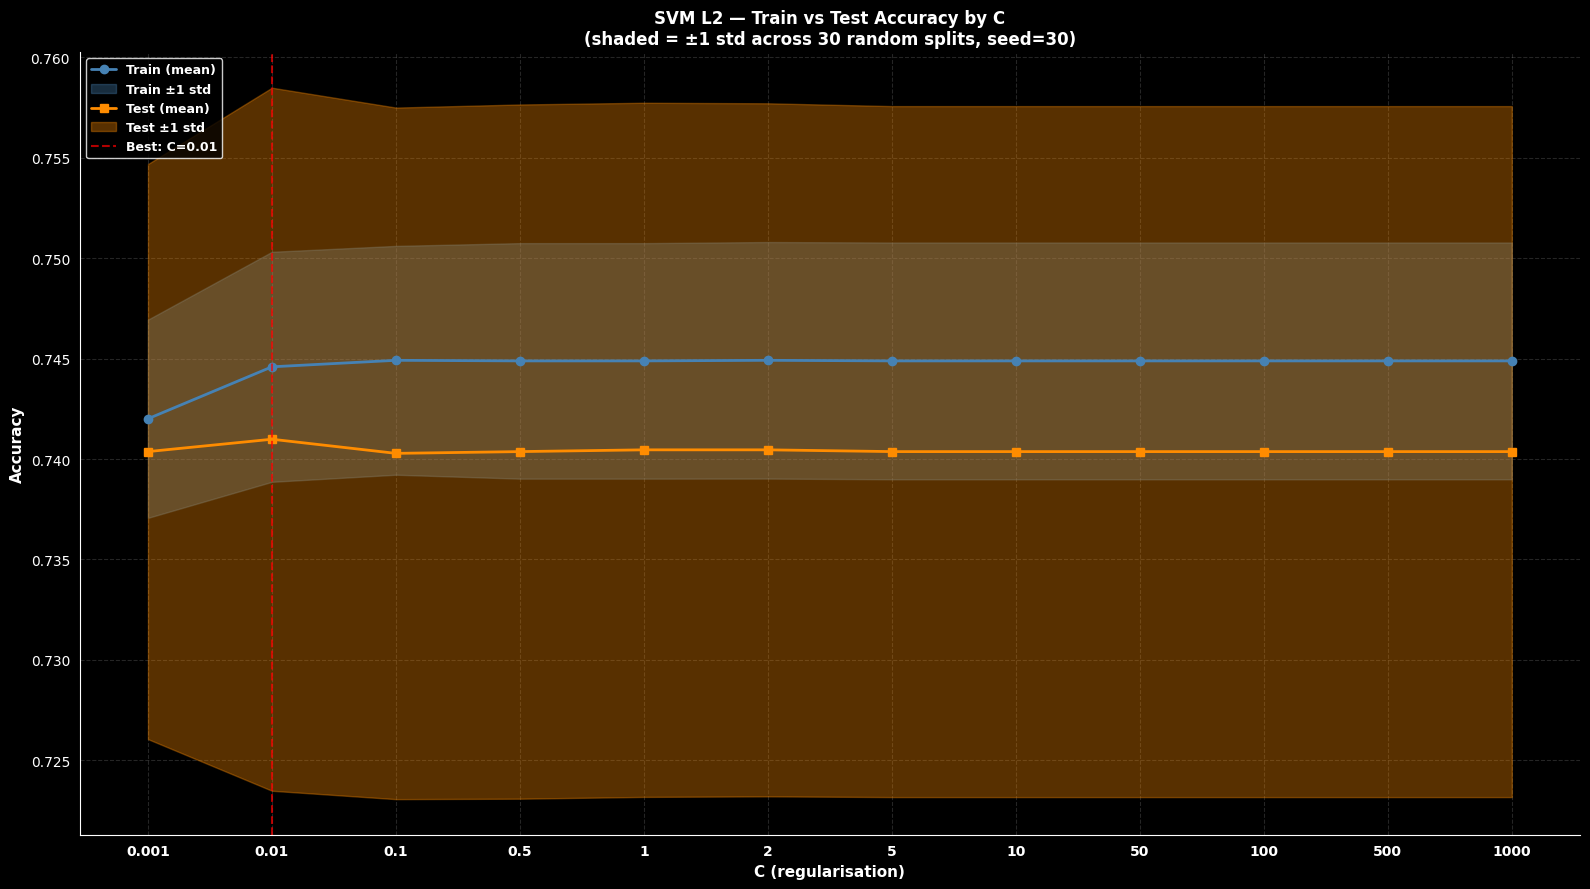

In [ ]:
svm_l2_mc_train, svm_l2_mc_test = mc_sweep(
    lambda c: Pipeline([('preprocessor', preprocessor),
                        ('svm', LinearSVC(C=c, penalty='l2', max_iter=10000))]),
    C_range_svm
)

best_c_idx_l2 = int(np.argmax(svm_l2_mc_test.mean(axis=1)))
best_c_svm_l2 = C_range_svm[best_c_idx_l2]
svm_l2_mc_train_mean = svm_l2_mc_train[best_c_idx_l2].mean()
svm_l2_mc_test_mean  = svm_l2_mc_test[best_c_idx_l2].mean()
print(f"Best C (by MC test mean): {best_c_svm_l2}")
print(f"MC Train (at best C)    : {svm_l2_mc_train_mean:.4f}")
print(f"MC Test  (at best C)    : {svm_l2_mc_test_mean:.4f}")
print(f"MC Gap                  : {abs(svm_l2_mc_train_mean - svm_l2_mc_test_mean):.4f}")

plot_mc_bands(C_range_svm, svm_l2_mc_train, svm_l2_mc_test,
              xlabel='C (regularisation)',
              title='SVM L2 — Train vs Test Accuracy by C',
              best_val=best_c_svm_l2, best_label=f'C={best_c_svm_l2}',
              x_labels=[str(c) for c in C_range_svm])


### 7.2 SVM L2 — Refit Best C + MC Final Score + Confusion Matrix

SVM L2 (C=0.01)  Train: 0.7372  Test: 0.7822
SVM-L2 MC (30 splits, seed=30): 0.7410 ± 0.0175


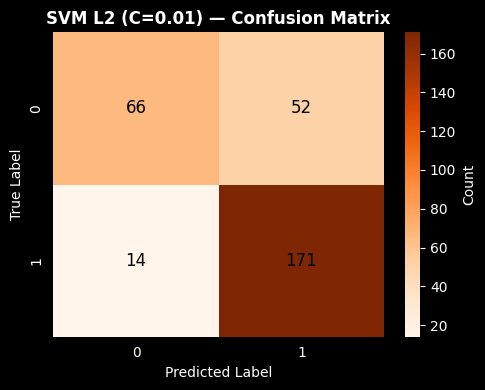


Confusion Matrix Metrics:
  TP:  171  TN:   66  FP:   52  FN:   14
  Accuracy : 0.7822
  Precision: 0.7668
  Recall   : 0.9243
  F1 Score : 0.8382


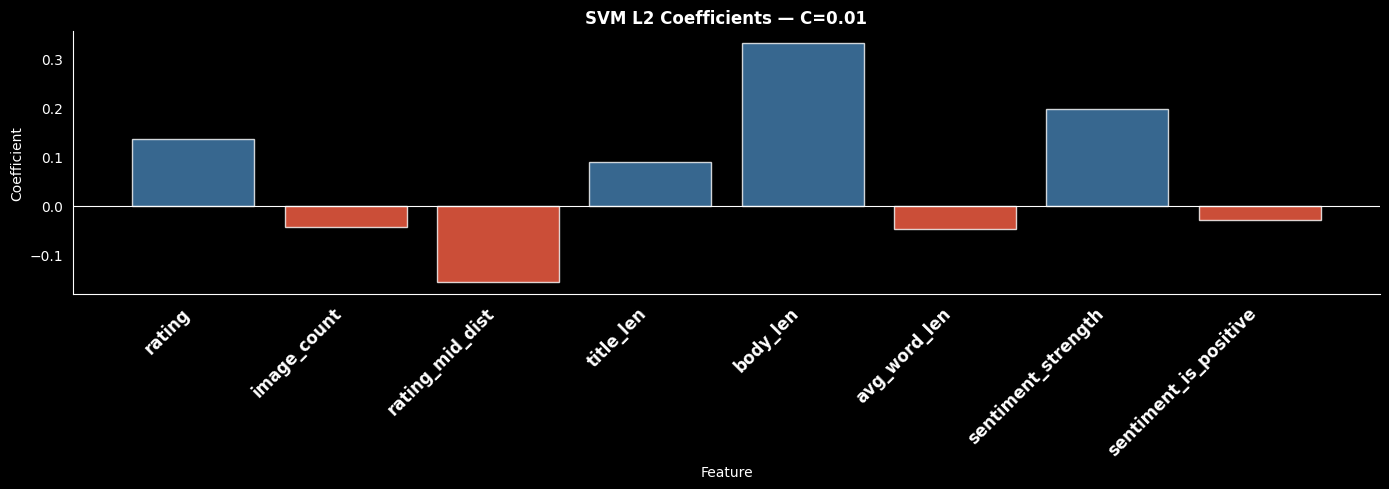

In [ ]:
svm_l2_best = Pipeline([('preprocessor', preprocessor),
                       ('svm', LinearSVC(C=best_c_svm_l2, penalty='l2', max_iter=10000))])
svm_l2_best.fit(X_train, y_train)
svm_l2_test_pred = svm_l2_best.predict(X_test)
print(f"SVM L2 (C={best_c_svm_l2})  Train: {svm_l2_best.score(X_train,y_train):.4f}  Test: {svm_l2_best.score(X_test,y_test):.4f}")

svm_l2_mc_mean, svm_l2_mc_std = mc_final_score(svm_l2_best, 'SVM-L2')
plot_confusion(y_test, svm_l2_test_pred, f'SVM L2 (C={best_c_svm_l2}) — Confusion Matrix', cmap='Oranges')
print("\nConfusion Matrix Metrics:")
print_cm_metrics(y_test, svm_l2_test_pred)

coef_l2_raw = svm_l2_best.named_steps['svm'].coef_.mean(axis=0)
fig, ax = plt.subplots(figsize=(14, 5), facecolor='black')
ax.set_facecolor('black')
ax.bar(range(len(all_feats)), coef_l2_raw,
       color=['tomato' if v < 0 else 'steelblue' for v in coef_l2_raw], alpha=0.8)
ax.axhline(0, color='white', lw=0.8)
ax.grid(False)
ax.set_xticks(range(len(all_feats)))
ax.set_xticklabels(all_feats, rotation=45, ha='right', fontsize=12, fontweight='bold', color='white')
ax.set_xlabel('Feature', color='white')
ax.set_ylabel('Coefficient', color='white')
ax.set_title(f'SVM L2 Coefficients — C={best_c_svm_l2}', fontweight='bold', color='white')
ax.tick_params(colors='white')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white')
ax.spines['bottom'].set_color('white')
plt.tight_layout()
plt.show()


---
## 8. Final Model Comparison




In [ ]:
all_models       = ['KNN','Decision Tree','Random Forest','XGBoost','LR-L1','LR-L2','SVM-L1','SVM-L2']
all_mc_means     = [knn_mc_mean,  dt_mc_mean,  rf_mc_mean,  xgb_mc_mean,
                    l1_mc_mean,   l2_mc_mean,  svm_l1_mc_mean, svm_l2_mc_mean]
all_mc_stds      = [knn_mc_std,   dt_mc_std,   rf_mc_std,   xgb_mc_std,
                    l1_mc_std,    l2_mc_std,   svm_l1_mc_std,  svm_l2_mc_std]
all_mc_train     = [knn_mc_train_mean, dt_mc_train_mean, rf_mc_train_mean, xgb_mc_train_mean,
                    l1_mc_train_mean,  l2_mc_train_mean, svm_l1_mc_train_mean, svm_l2_mc_train_mean]
all_mc_test      = [knn_mc_test_mean,  dt_mc_test_mean,  rf_mc_test_mean,  xgb_mc_test_mean,
                    l1_mc_test_mean,   l2_mc_test_mean,  svm_l1_mc_test_mean,  svm_l2_mc_test_mean]
all_cv_scores    = [knn_grid.best_score_, dt_grid.best_score_,
                    rf_grid.best_score_,  xgb_grid.best_score_,
                    l1_grid.best_score_,  l2_grid.best_score_,
                    svm_l1_mc_test.mean(axis=1).max(),
                    svm_l2_mc_test.mean(axis=1).max()]

# Best model: MC mean first, CV score as tiebreaker
best_mc  = max(all_mc_means)
top_idxs = [i for i, m in enumerate(all_mc_means) if abs(m - best_mc) < 1e-6]
best_idx = top_idxs[0] if len(top_idxs) == 1 else max(top_idxs, key=lambda i: all_cv_scores[i])

summary = pd.DataFrame({
    'Model'        : all_models,
    'MC Train'     : [f'{a:.4f}' for a in all_mc_train],
    'MC Test'      : [f'{a:.4f}' for a in all_mc_test],
    'MC Gap'       : [f'{abs(tr-te):.4f}' for tr,te in zip(all_mc_train, all_mc_test)],
    'CV Score'     : [f'{s:.4f}' for s in all_cv_scores],
    'MC Mean'      : [f'{m:.4f}' for m in all_mc_means],
    'MC Std'       : [f'{s:.4f}' for s in all_mc_stds],
})


summary.style.highlight_max(subset=['MC Mean'], color='lightgreen') \
             .highlight_min(subset=['MC Std'],  color='lightblue')


,Model,MC Train,MC Test,MC Gap,CV Score,MC Mean,MC Std
0,KNN,0.7529,0.7303,0.0227,0.7157,0.7247,0.0175
1,Decision Tree,0.7524,0.7256,0.0268,0.7124,0.7256,0.0197
2,Random Forest,0.7811,0.7444,0.0367,0.7322,0.7444,0.0176
3,XGBoost,0.7935,0.7441,0.0494,0.7413,0.7441,0.0174
4,LR-L1,0.7445,0.7408,0.0037,0.7289,0.7408,0.0198
5,LR-L2,0.7466,0.7424,0.0042,0.7372,0.7424,0.0181
6,SVM-L1,0.7463,0.7412,0.0051,0.7412,0.7412,0.0173
7,SVM-L2,0.7446,0.7410,0.0036,0.7410,0.7410,0.0175


### 8.1 MC Mean Accuracy — All Models

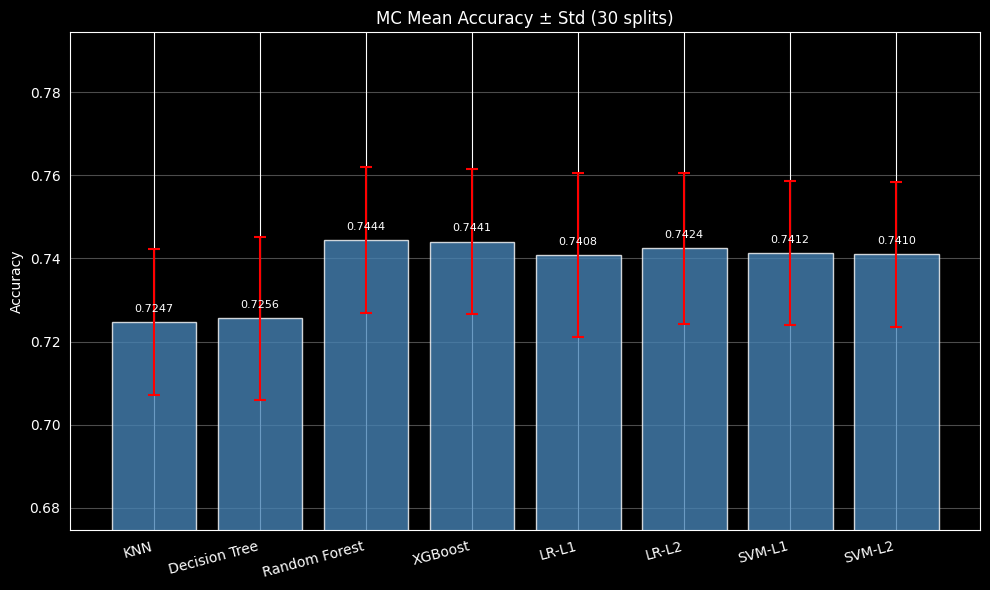

In [ ]:
fig, ax = plt.subplots(figsize=(10, 6))

x = np.arange(len(all_models))
bars = ax.bar(x, all_mc_means, alpha=0.8, color='steelblue',
              yerr=all_mc_stds, capsize=4,
              error_kw=dict(ecolor='red', capthick=1.5, elinewidth=1.5))
ax.set_xticks(x); ax.set_xticklabels(all_models, rotation=15, ha='right')
ax.set_ylabel('Accuracy'); ax.set_title('MC Mean Accuracy ± Std (30 splits)')
ax.grid(True, alpha=0.3, axis='y')
ax.set_ylim(min(all_mc_means) - 0.05, max(all_mc_means) + 0.05)
for b, m in zip(bars, all_mc_means):
    ax.text(b.get_x() + b.get_width()/2, m + 0.002, f'{m:.4f}',
            ha='center', va='bottom', fontsize=8)

plt.tight_layout(); plt.show()

### 8.2 Gradient Bar Chart

### 8.3 Highlighted Gradient Bar Chart

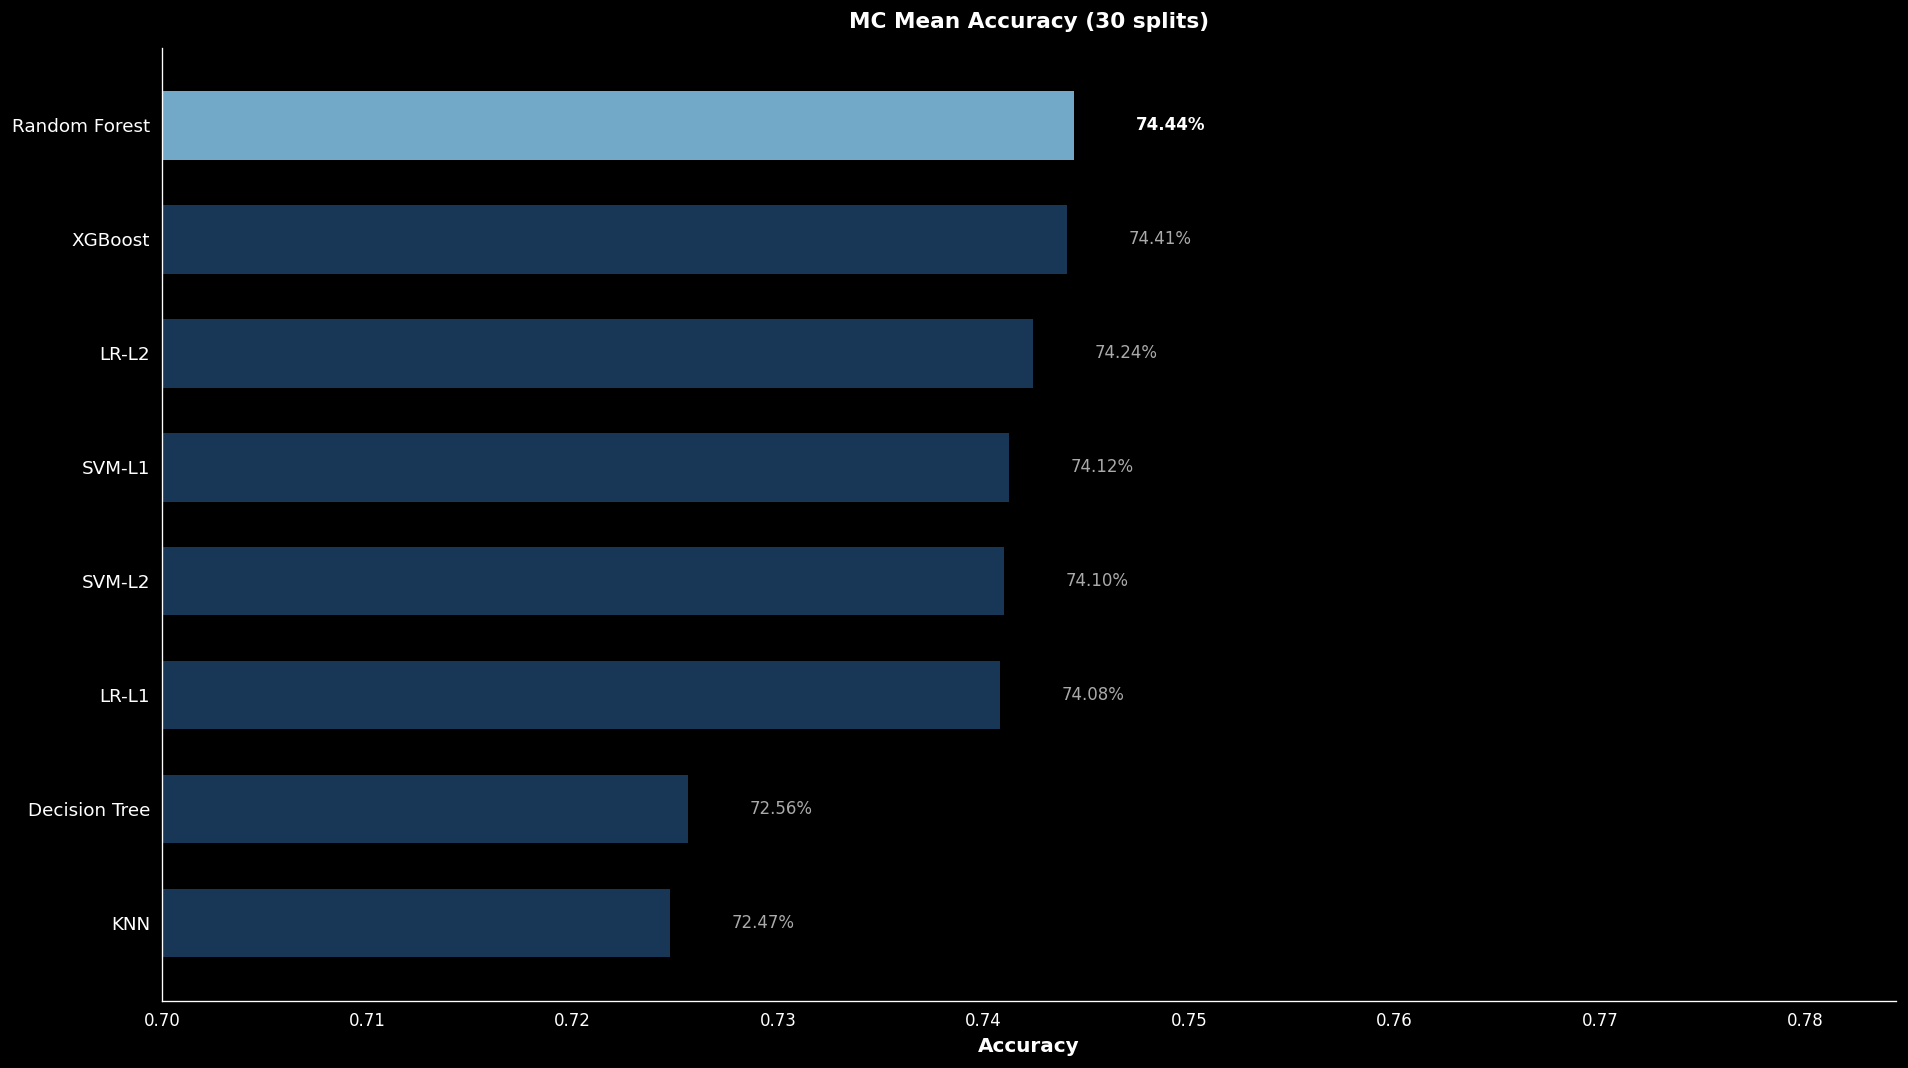

In [ ]:
fig, ax = plt.subplots(figsize=(16, 9), dpi=120, facecolor='black')
ax.set_facecolor('black')

cmap_blue = LinearSegmentedColormap.from_list('blue_grad', ['#a8d4f5', '#1a5c8a'])
sorted_pairs  = sorted(zip(all_mc_means, all_models), reverse=True)
sorted_means  = [v for v, _ in sorted_pairs]
sorted_models = [m for _, m in sorted_pairs]

val_min, val_max = min(sorted_means), max(sorted_means)
y_pos = np.arange(len(sorted_models))
highlight_models = {'Random Forest'}

cmap_dark = LinearSegmentedColormap.from_list('pale_grad', ['#d0e8f5', '#7ab3d4'])
cmap_pale = LinearSegmentedColormap.from_list('dark_grad', ['#4a90c4', '#1a3a5c'])

for i, (model, val) in enumerate(zip(sorted_models, sorted_means)):
    cmap = cmap_dark if model in highlight_models else cmap_pale
    n_grad  = 300
    x_steps = np.linspace(0, val, n_grad)
    for k in range(n_grad - 1):
        shade = cmap(0.2 + (x_steps[k] / val) * 0.8 + 0.1)
        ax.barh(i, x_steps[k+1] - x_steps[k], left=x_steps[k],
                height=0.6, color=shade, alpha=0.95, linewidth=0, edgecolor='none')
    label_color  = 'white' if model in highlight_models else '#aaaaaa'
    label_weight = 'bold'  if model in highlight_models else '400'
    ax.text(val + 0.003, i, f'{val*100:.2f}%',
            va='center', ha='left', fontsize=10, fontweight=label_weight, color=label_color)

ax.set_yticks(y_pos)
ax.set_yticklabels(sorted_models, fontsize=11, color='white')
ax.set_xlabel('Accuracy', fontsize=12, color='white', fontweight='bold')
ax.set_title('MC Mean Accuracy (30 splits)', fontsize=13, fontweight='bold', pad=12, color='white')
ax.set_xlim(0.70, max(sorted_means) + 0.04)
ax.grid(False); ax.invert_yaxis()
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('white'); ax.spines['bottom'].set_color('white')
ax.tick_params(colors='white')
plt.tight_layout(); plt.show()


### 8.4 MC Score Distribution — All Models

/tmp/ipykernel_1047/1517689310.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(all_mc_dist.values(), labels=all_mc_dist.keys(), patch_artist=True,


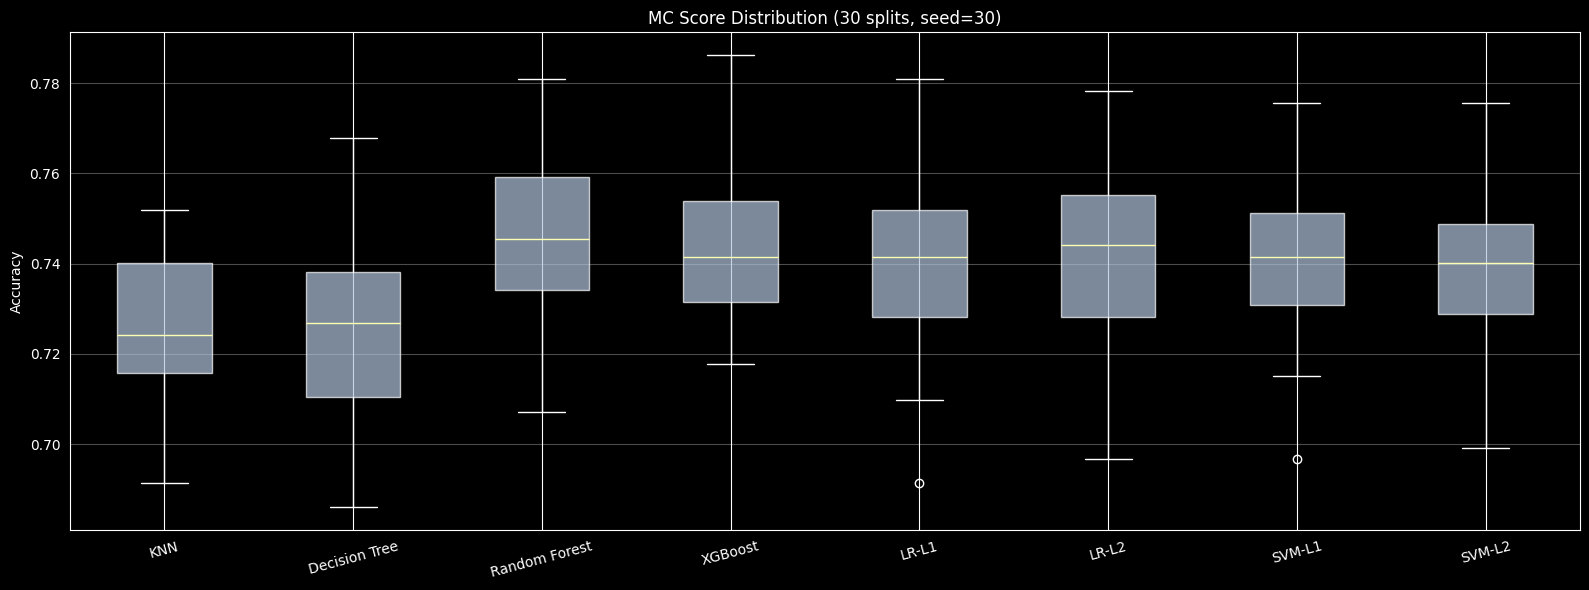

In [ ]:
all_mc_dist = {}
for name, pipe in zip(all_models,
                      [knn_best, dt_best, rf_best, xgb_best,
                       l1_best, l2_best, svm_l1_best, svm_l2_best]):
    all_mc_dist[name] = cross_val_score(
        pipe, X, y,
        cv=ShuffleSplit(N_MC_FINAL, test_size=0.25, random_state=MC_SEED),
        scoring='accuracy', n_jobs=-1)

fig, ax = plt.subplots(figsize=(16, 6))
ax.boxplot(all_mc_dist.values(), labels=all_mc_dist.keys(), patch_artist=True,
           boxprops=dict(facecolor='lightsteelblue', alpha=0.7))
ax.set_ylabel('Accuracy')
ax.set_title(f'MC Score Distribution ({N_MC_FINAL} splits, seed={MC_SEED})')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout(); plt.show()


### 8.5 Hyperparameter Results Table

In [ ]:
best_hparams = [
    clean_params(knn_grid.best_params_),
    clean_params(dt_grid.best_params_),
    clean_params(rf_grid.best_params_),
    clean_params(xgb_grid.best_params_),
    f"C={l1_grid.best_params_['lr__C']}, penalty=L1",
    f"C={l2_grid.best_params_['lr__C']}, penalty=L2",
    f"C={best_c_svm_l1}, penalty=L1",
    f"C={best_c_svm_l2}, penalty=L2",
]

results_table = pd.DataFrame({
    'Model'               : all_models,
    'Best Hyperparameters': best_hparams,
    'MC Train'            : [f'{a:.4f}' for a in all_mc_train],
    'MC Test'             : [f'{a:.4f}' for a in all_mc_test],
    'MC Mean'             : [f'{m:.4f}' for m in all_mc_means],
    'MC Std'              : [f'{s:.4f}' for s in all_mc_stds],
})

pd.set_option('display.max_colwidth', None)
results_table


,Model,Best Hyperparameters,MC Train,MC Test,MC Mean,MC Std
0,KNN,"{'metric': 'manhattan', 'k': 24, 'weights': 'distance'}",0.7529,0.7303,0.7247,0.0175
1,Decision Tree,"{'criterion': 'gini', 'max_depth': 3, 'min_leaf': 1, 'min_split': 2}",0.7524,0.7256,0.7256,0.0197
2,Random Forest,"{'max_depth': 5, 'max_feat': 'sqrt', 'n_est': 300}",0.7811,0.7444,0.7444,0.0176
3,XGBoost,"{'lr': 0.02, 'max_depth': 3, 'n_est': 400}",0.7935,0.7441,0.7441,0.0174
4,LR-L1,"C=1, penalty=L1",0.7445,0.7408,0.7408,0.0198
5,LR-L2,"C=0.1, penalty=L2",0.7466,0.7424,0.7424,0.0181
6,SVM-L1,"C=0.1, penalty=L1",0.7463,0.7412,0.7412,0.0173
7,SVM-L2,"C=0.01, penalty=L2",0.7446,0.7410,0.7410,0.0175
